**Installations**

Uncomment and run, the first time you use this notebook.

In [116]:
# ! pip install pycirclize

In [ ]:
# Imports

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import pycirclize
from pycirclize import Circos
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.cm as cm
import os
import plotly.graph_objects as go
import networkx as nx
import plotly.express as px
import plotly.io as pio
from collections import defaultdict
import matplotlib
from itertools import combinations
import math
from plotly.colors import sample_colorscale
import os
import h5py
from sklearn.manifold import TSNE
import glasbey
import re

**File directories**

Make changes for the input and output paths and directories here.

In [118]:
# Input files used for analysis
Cluster_detail_results = pd.read_csv( os.path.join(r'Y:\3darena_behavior\mitopark\mitopark_042025\042025_2mp\week8-10-12-14-23Comp_video\Combined_Results\Results\test1\Cluster_detail_results.csv') )
filename = r"Y:\3darena_behavior\mitopark\mitopark_042025\042025_2mp\week8-10-12-14-23Comp_video\Combined_Results\Results\test1\session_1_out.mat"
filename_groups = r'Z:\Members\Mia-Sanjana-Hadent\Processed Data\042025_2mp\cluster_groups_matlab.csv'

# Output directory for all data
output_path = r"D:\AccelClusterVisualizations\AccelCluster-Visualizations\data"
os.makedirs(output_path, exist_ok=True)

# Output directory for all Graphs
output_dir = r'D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs'
os.makedirs(output_dir, exist_ok=True)

# Use any label for mouse
mouse_name = "2mp"  

Stitched Labeled Experiment - Create combined_matrix.csv before creating visuals

In [119]:
# Read in values from clustersIdx, set automatically to the cluster value it represents rather than the actual value of the cell
if os.path.exists(filename):
    with h5py.File(filename, 'r') as file:
        library = file['Library']
        clustersIdx = library['clustersIdx']
        
        group_labels = []
        for i in range(clustersIdx.shape[0]):
            idxref = clustersIdx[i, 0]
            cluster_indices = np.array(file[idxref]).flatten()
            group_labels.extend([i+1] * len(cluster_indices))
        
        group_labels_df = pd.DataFrame(group_labels, columns=['GroupLabel'])
        print(f"Group labels shape: {group_labels_df.shape}")
else:
    raise FileNotFoundError('Could not find session_1_out.mat in dedicated subdirectory')


# Read in the feature values from clusters and stack on top of each other
if os.path.exists(filename):
    print('Loading session file from expected Results/test1 directory')
    with h5py.File(filename, 'r') as file:
        if 'Library' not in file:
            raise KeyError("The key 'Library' was not found in the session file.")
        library = file['Library']
        clusters = library['clusters']
        
        features_data = []
        
        for i in range(clusters.shape[0]):
            cref = clusters[i, 0]
            feature_data = np.array(file[cref]).T 
            features_data.append(feature_data)
        
        features_matrix = np.vstack(features_data)
        features_df = pd.DataFrame(features_matrix)
        print(f"Loaded {len(features_data)} clusters with total points: {features_matrix.shape[0]}")
        print(f"Combined matrix shape: {features_matrix.shape}")
else:
    raise FileNotFoundError('Could not find session_1_out.mat in dedicated subdirectory')
features_df['cluster'] = group_labels_df['GroupLabel'].values


# Create combined matrix by matching first occurrence of each cluster in features_df to first occurrence in Cluster_detail_results, keeping order of Cluster_detail_results
def match_features_to_details(features_df, detail_df):
    matched_rows = []
    cluster_counts = {}
    for idx, detail_row in detail_df.iterrows():
        cluster_val = detail_row['ClusterIdx']
        count = cluster_counts.get(cluster_val, 0)
        feature_rows = features_df[features_df['cluster'] == cluster_val]
        if count < len(feature_rows):
            feature_row = feature_rows.iloc[count]
            combined_row = feature_row.to_dict()
            combined_row['Timestamp'] = detail_row['Timestamp'] if 'Timestamp' in detail_row else None
            combined_row['ClusterIdx'] = cluster_val
            combined_row['Folder_Name'] = detail_row['Folder_Name'] if 'Folder_Name' in detail_row else None
            matched_rows.append(combined_row)
            cluster_counts[cluster_val] = count + 1
        else:
            combined_row = {col: None for col in features_df.columns}
            combined_row['Timestamp'] = detail_row['Timestamp'] if 'Timestamp' in detail_row else None
            combined_row['ClusterIdx'] = cluster_val
            combined_row['Folder_Name'] = detail_row['Folder_Name'] if 'Folder_Name' in detail_row else None
            matched_rows.append(combined_row)
    return pd.DataFrame(matched_rows)

combined_matrix = match_features_to_details(features_df, Cluster_detail_results)

# Automatically detects Week_Number from Folder_Name based on pattern of 'weekXX'
def get_week_number(folder_name):
    if isinstance(folder_name, str):
        match = re.search(r'week(\d+)', folder_name)
        if match:
            return int(match.group(1))
    return None

combined_matrix['Week_Number'] = combined_matrix['Folder_Name'].apply(get_week_number)
combined_matrix['Week_Number'] = combined_matrix['Week_Number'].fillna(0).astype(int)
combined_matrix = combined_matrix[combined_matrix['Week_Number'] != 0]

# Clean up the finalized combined df (Column Titles : "Feature 1" ... "Feature 30" , "Timestamp" , "Cluster", "Week_Number")
feature_cols = {i: f'Feature{i+1}' for i in range(30)}
combined_matrix = combined_matrix.rename(columns=feature_cols)
combined_matrix = combined_matrix.drop(columns=['cluster'])
combined_matrix = combined_matrix.drop(columns=['Folder_Name'])
combined_matrix = combined_matrix.rename(columns={'ClusterIdx': 'Cluster'})

# Save combined_matrix file
output_file = os.path.join(output_path, f"combined_matrix_{mouse_name}.csv")
combined_matrix.to_csv(output_file, index=False)
print(f"Saved as {output_file}")
print(combined_matrix.head())

Group labels shape: (121067, 1)
Loading session file from expected Results/test1 directory
Loaded 97 clusters with total points: 121067
Combined matrix shape: (121067, 30)
Saved as D:\AccelClusterVisualizations\AccelCluster-Visualizations\data\combined_matrix_2mp.csv
   Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  Feature7  \
0       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
1       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
2       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
3       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
4       0.0       0.0       0.0       0.0       0.0       0.0       0.0   

   Feature8  Feature9  Feature10  ...  Feature24  Feature25  Feature26  \
0  0.016667  0.983333   0.000000  ...   0.150000   0.366667   0.366667   
1  0.000000  0.033333   0.966667  ...   0.066667   0.316667   0.300000   
2  0.000000  0.000000   1.000000  ...   0.233333   0.350000

**Function Definitions**

In [120]:
# -------------------- t-SNE --------------------
# Automatically find the number of stages
weeks = combined_matrix['Week_Number'].unique()
stage_names = [f"Stage {i}" for i in range(1, len(weeks) + 1)]

# Automatically find the total number of clusters
num_clusters = combined_matrix['Cluster'].max()

# Compute t-SNE embedding (if not precomputed)
features = combined_matrix.iloc[:, 0:30].values.astype(float)
tsne = TSNE(n_components=2, perplexity=30, learning_rate=100, random_state=42)
Y = tsne.fit_transform(features)
combined_matrix['TSNE-1'] = Y[:, 0]
combined_matrix['TSNE-2'] = Y[:, 1]

# Get all clusters present across the ENTIRE dataset
all_clusters = sorted(combined_matrix['Cluster'].unique())
cluster_labels_str = [str(c) for c in all_clusters]

# Create color pallette
glasbey_palette = glasbey.create_palette(palette_size=num_clusters)
cluster_to_color = {
    str(c): glasbey_palette[i % num_clusters]
    for i, c in enumerate(all_clusters)
}

In [121]:
# -------------------- Circular Heatmap --------------------
def create_cluster_usage_df( df ):
    df = pd.DataFrame( df )

    df_cluster_usage = df['Cluster'].value_counts().reset_index()
    df_cluster_usage.columns = ['Cluster', 'count']
    df_cluster_usage['count'] = df_cluster_usage['count'].astype( int )
    total_count = df_cluster_usage['count'].sum()
    df_cluster_usage['percentage'] = df_cluster_usage['count'] / total_count * 100

    return df_cluster_usage

def compute_cluster_usage_change( week_dfs, week_early, week_late ):

    df_early = week_dfs[week_early]
    df_late = week_dfs[week_late]

    merged_df = pd.merge(
        df_early, df_late,
        on='Cluster', how='right',
        suffixes=(f'_{week_early}', f'_{week_late}')
    )

    merged_df[f'percentage_{week_early}'] = merged_df[f'percentage_{week_early}'].fillna(0)
    merged_df['change_in_usage'] = merged_df[f'percentage_{week_late}'] - merged_df[f'percentage_{week_early}']

    return merged_df[['Cluster', f'percentage_{week_early}', f'percentage_{week_late}', 'change_in_usage']]

def create_heatmaps_variable_periods(
    dfs,
    save=False,
    paths=None,
    global_min=None,
    global_max=None,
    keys=None
):
   
    # Filter each DataFrame to same cluster range
    dfs = [df[(df['Cluster'] >= 1) & (df['Cluster'] <= 72)] for df in dfs]

    # Determine global color scale across all DataFrames
    all_changes = np.concatenate([df['change_in_usage'].values for df in dfs])
    if global_min is None:
        global_min = all_changes.min()
    if global_max is None:
        global_max = all_changes.max()

    # global_min = -4.774236665
    # global_max = 4.531974437158014

    norm = TwoSlopeNorm(vmin=global_min, vcenter=0, vmax=global_max)

    # Determine consistent cluster order (based on ascending ClusterNumber)
    all_clusters = sorted(set(np.concatenate([df['Cluster'].unique() for df in dfs])))

    def convert_key_to_stage_label(key):
        tokens = key.split("_")
        stage_nums = []

        for t in tokens:
            # extract digits from token (e.g., "week12" → "12")
            digits = ''.join(ch for ch in t if ch.isdigit())
            if digits:
                stage_nums.append(int(digits))
        
        # Safety check: must have 2 stages
        if len(stage_nums) != 2:
            return key  # fallback
        
        return f"Stage {stage_nums[0]} → Stage {stage_nums[1]}"


    titles = [
        f"Change in Cluster Usage Percentage - {convert_key_to_stage_label(key)}"
        for key in keys
    ]

    # Iterate through each DataFrame
    for i, df in enumerate(dfs):
        # Reorder to consistent cluster order
        df_ordered = (
            df.set_index("Cluster")
              .reindex(all_clusters)
              .fillna({"change_in_usage": 0})
              .reset_index()
        )

        clusters = df_ordered["Cluster"].astype(int).values
        change_values = df_ordered["change_in_usage"].values
        colors = plt.cm.bwr(norm(change_values))

        # Create polar plot
        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})
        theta = np.linspace(0, 2 * np.pi, len(clusters), endpoint=False)
        slice_width = 2 * np.pi / len(clusters)
        bar_width = slice_width * 0.9
        ax.bar(theta, np.ones(len(clusters)), color=colors, width=bar_width, bottom=0.5)

        # Axis formatting
        ax.set_xticks(theta)
        ax.set_xticklabels(clusters, fontsize=5.5, rotation=45)
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.tick_params(axis="x", pad=-8)
        ax.grid(False)
        ax.spines["polar"].set_visible(False)

        # Colorbar (same normalization across all plots)
        sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.1)
        cbar.set_label("Change in Usage Percentage")

        plt.title(titles[i])
        plt.tight_layout()

        # --- Optional saving
        if save and paths and i < len(paths):
            path = paths[i]
            eps_dir = os.path.dirname(path)
            if eps_dir:
                os.makedirs(eps_dir, exist_ok=True)

            base_filename = os.path.splitext(os.path.basename(path))[0]
            eps_path = os.path.join(eps_dir, base_filename + ".eps")
            plt.savefig(eps_path, format="eps", bbox_inches="tight")
            print(f"EPS saved to: {eps_path}")

            parent_dir = os.path.dirname(eps_dir)
            png_dir = os.path.join(parent_dir, "png")
            os.makedirs(png_dir, exist_ok=True)
            png_path = os.path.join(png_dir, base_filename + ".png")
            plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")
            print(f"PNG saved to: {png_path}")

        plt.show()

In [122]:
# -------------------- Circular Heatmap --------------------
all_df = combined_matrix
week_map = {wk: i+1 for i, wk in enumerate(sorted(all_df["Week_Number"].unique()))}
all_df["Week_Number"] = combined_matrix["Week_Number"].replace(week_map)

# Creates list of dfs, one for each unique week within the dataset
stage_dfs = {
    f"stage{int(week)}": group_df.sort_values(by="Cluster", ascending=True).copy()
    for week, group_df in all_df.groupby("Week_Number", sort=True)
}

In [123]:
# -------------------- Cluster Level Char --------------------
## Calculate time spent in each cluster - Start Time, End Time, Duration, Cluster, Folder Name
def extract_bouts(df):
    df = df.reset_index(drop=True)
    change = df['Cluster'] != df['Cluster'].shift()
    starts = df.index[change]
    ends = list(starts[1:]) + [len(df)-1]

    bout_data = []
    for start, end in zip(starts, ends):
        duration = df.loc[end, 'Timestamp'] - df.loc[start, 'Timestamp'] + 1
        bout_data.append({
            'start_timestamp': df.loc[start, 'Timestamp'],
            'end_timestamp': df.loc[end, 'Timestamp'],
            'duration': duration,
            'Cluster': df.loc[start, 'Cluster'],
            'Week_Number': df.loc[start, 'Week_Number']
        })
    return pd.DataFrame(bout_data)

In [124]:
# -------------------- Sankey with Pie Plots --------------------
all_data = combined_matrix
grouped_clusters = pd.read_csv(os.path.join(filename_groups))

# Pie Flow Chart
custom_colors_pies = [  
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32",
    "#1e90ff", "#ff1493", "#00ced1", "#ff69b4", "#7cfc00", "#ff6347", "#00ff7f", "#4682b4",
    "#da70d6", "#40e0d0", "#dc143c", "#00bfff", "#ff8c00", "#9932cc", "#8b0000", "#00fa9a",
    "#6495ed", "#ba55d3", "#f0e68c", "#ff00ff", "#00ffff", "#adff2f", "#ffa500", "#87ceeb",
    "#f08080", "#20b2aa", "#f5deb3", "#ffb6c1", "#2e8b57", "#ffdab9", "#b0e0e6", "#cd5c5c",
    "#dda0dd", "#fa8072", "#eee8aa", "#7fffd4", "#b22222", "#8fbc8f", "#ffdead", "#ff7f50",
    "#ffefd5", "#5f9ea0", "#ff69b4", "#bdb76b", "#8a2be2", "#ff1493", "#d2691e", "#bc8f8f",
    "#8b4513", "#00ced1", "#b0c4de", "#ffe4e1", "#2f4f4f", "#696969", "#d2b48c", "#fafad2"
]

week_numbers = sorted(all_data['Week_Number'].dropna().unique())

def create_sankey_and_pies(data, week_number, mouse_name=""):
    data = data.copy()
    data['Next_Cluster'] = data['Cluster'].shift(-1)
    data['Next_Week_Number'] = data['Week_Number'].shift(-1)
    data = data[data['Week_Number'] == data['Next_Week_Number']]

    transition_counts = data.groupby(['Cluster', 'Next_Cluster']).size().unstack(fill_value=0)
    transition_probabilities = transition_counts.div(transition_counts.sum(axis=1), axis=0)
    all_clusters = sorted(data['Cluster'].dropna().astype(int).unique())
    outgoing_counts = {f"Cluster {i}": 0 for i in all_clusters}
    incoming_counts = {f"Cluster {i}": 0 for i in all_clusters}

    for col in transition_probabilities.columns:
        for row in transition_probabilities.index:
            prob = transition_probabilities.at[row, col]
            if prob > 0:
                src = f"Cluster {int(row)}"
                tgt = f"Cluster {int(col)}"
                if src in outgoing_counts:
                    outgoing_counts[src] += 1
                if tgt in incoming_counts:
                    incoming_counts[tgt] += 1

    print(f"\n--- Incoming and Outgoing Flow Counts for Week {week_number} ---")


    def plot_pie_chart(counts, title, png_dir=None, eps_dir=None):
        labels = list(counts.keys())
        sizes = list(counts.values())
        total = sum(sizes)

        display_labels = [
            label.replace("Cluster ", "") if (value / total * 100) >= 1 else ""
            for label, value in zip(labels, sizes)
        ]

        pie_colors = [custom_colors_pies[int(label.split()[1]) % len(custom_colors_pies)] for label in labels]

        plt.figure(figsize=(6, 6))
        plt.pie(
            sizes,
            labels=display_labels,
            colors=pie_colors,
            startangle=140,
            textprops={'fontsize': 8}
        )
        plt.title(title, pad=10)
        plt.axis('equal')
        
        
        plt.savefig(eps_dir, format="eps", bbox_inches="tight")
        print(f"EPS saved to: {eps_dir}")

        plt.savefig(png_dir, format="png", dpi=300, bbox_inches="tight")
        print(f"PNG saved to: {png_dir}")

        plt.show()

    incoming_chart_counts = {k: v for k, v in incoming_counts.items() if v > 0}
    outgoing_chart_counts = {k: v for k, v in outgoing_counts.items() if v > 0}

    png_dir = os.path.join( output_dir , r'sankey_with_pie_plots\png' )
    os.makedirs(png_dir, exist_ok=True)
    eps_dir = os.path.join( output_dir , r'sankey_with_pie_plots\eps' )
    os.makedirs(eps_dir, exist_ok=True)
    
    incoming_path_png = os.path.join(
        png_dir,
        f"{mouse_name}_week{week_number}_incoming.png"
    )
    outgoing_path_png = os.path.join(
        png_dir,
        f"{mouse_name}_week{week_number}_outgoing.png"
    )
    incoming_path_eps = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_incoming.eps"
    )
    outgoing_path_eps = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_outgoing.eps"
    )
    
    plot_pie_chart(incoming_chart_counts, f"Incoming Flows - Week {week_number}", incoming_path_png, incoming_path_eps)
    plot_pie_chart(outgoing_chart_counts, f"Outgoing Flows - Week {week_number}", outgoing_path_png, outgoing_path_eps)

In [125]:
# -------------------- Sankey with Pie Plots --------------------
# Sankeys Grouped
custom_colors_sankey = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32"
]

group_list = sorted(grouped_clusters['Group'].dropna().unique())
color_map = {int(group): custom_colors_sankey[i % len(custom_colors_sankey)] for i, group in enumerate(group_list)}

def map_grouped_clusters(df):
    return df.merge(grouped_clusters[['Cluster', 'Group']], left_on='Cluster', right_on='Cluster', how='left')

def create_grouped_sankey_plot(data, week_number, mouse_name=''):
    data = map_grouped_clusters(data)
    data['Next_Group'] = data['Group'].shift(-1)
    data = data.dropna(subset=['Group', 'Next_Group'])

    data['Group'] = data['Group'].astype(int)
    data['Next_Group'] = data['Next_Group'].astype(int)

    unique_groups = sorted(set(data['Group']).union(set(data['Next_Group'])))
    group_labels = [f"Group {g}" for g in unique_groups]
    label_indices = {f"Group {g}": i for i, g in enumerate(unique_groups)}
    n = len(unique_groups)

    transition_counts = data.groupby(['Group', 'Next_Group']).size().unstack(fill_value=0)
    transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)

    source, target, values, colors = [], [], [], []

    for src in transition_probs.index:
        for tgt in transition_probs.columns:
            prob = transition_probs.at[src, tgt]
            if prob > 0:
                src_label = f"Group {src}"
                tgt_label = f"Group {tgt}"
                source.append(label_indices[src_label])
                target.append(label_indices[tgt_label] + n)
                values.append(prob)
                colors.append(color_map[src])

    scale = 0.6 
    offset = (1 - scale) / 2 
    y_values = [offset + scale * (i / (n - 1)) for i in range(n)] if n > 1 else [0.5]
    y_positions = y_values * 2
    x_positions = [0.1] * n + [0.9] * n

    fig = go.Figure(go.Sankey(
        node=dict(
            pad=20,
            thickness=25,
            line=dict(color="black", width=0.5),
            label=group_labels * 2,
            color="lightgray",
            x=x_positions,
            y=y_positions
        ),
        link=dict(
            source=source,
            target=target,
            value=values,
            color=colors
        )
    ))

    fig.update_layout(
        title_text=f"Grouped Cluster Transitions in Week {week_number}",
        font_size=12,
        height=1000,
        width=1000,
        margin=dict(l=10, r=100, t=50, b=50) 
    )

    png_dir = os.path.join( output_dir , r'sankey_with_pie_plots\png' )
    os.makedirs(png_dir, exist_ok=True)
    eps_dir = os.path.join( output_dir , r'sankey_with_pie_plots\eps' )
    os.makedirs(eps_dir, exist_ok=True)
    
    base_filename = f"sankey_{mouse_name}_stage{week_number}"

    eps_path = os.path.join(eps_dir, base_filename + ".svg")
    fig.write_image(eps_path)
    print(f"SVG saved to: {eps_path}")

    png_path = os.path.join(png_dir, base_filename + ".png")
    fig.write_image(png_path)
    print(f"PNG saved to: {png_path}")

    fig.show()

In [126]:
# -------------------- Sankey with Pie Plots --------------------
# Pie Flow Chart Grouped

custom_colors_pies_grouped = [
    "#32cd32", "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32",
]

def create_group_pie_flows(data, week_number, mouse_name=""):
    data = data.copy()

    cluster_to_group = dict(zip(grouped_clusters['Cluster'], grouped_clusters['Group']))
    data['Group'] = data['Cluster'].map(cluster_to_group)

    data['Next_Group'] = data['Group'].shift(-1)
    data = data.dropna(subset=['Group', 'Next_Group'])

    data['Group'] = data['Group'].astype(int)
    data['Next_Group'] = data['Next_Group'].astype(int)

    all_groups = sorted(set(data['Group']).union(set(data['Next_Group'])))
    outgoing_counts = {f"Group {i}": 0 for i in all_groups}
    incoming_counts = {f"Group {i}": 0 for i in all_groups}

    for _, row in data.iterrows():
        src = f"Group {int(row['Group'])}"
        tgt = f"Group {int(row['Next_Group'])}"
        outgoing_counts[src] += 1
        incoming_counts[tgt] += 1


    print(f"--- Group Flow Counts for Week {week_number} ---")

    def plot_pie_chart(counts, title, png_dir=None, eps_dir=None):
        labels = list(counts.keys())
        sizes = list(counts.values())
        pie_colors = [custom_colors_pies_grouped[int(label.split()[-1]) % len(custom_colors_pies_grouped)] for label in labels]
        plt.figure(figsize=(6, 6))
        plt.pie(
            sizes,
            labels=[label.replace("Group ", "") for label in labels],
            colors=pie_colors,
            startangle=140,
            textprops={'fontsize': 8}
        )
        plt.title(title, pad=10)
        plt.axis('equal')

        plt.savefig(eps_dir, format="eps", bbox_inches="tight")
        print(f"EPS saved to: {eps_dir}")

        plt.savefig(png_dir, format="png", dpi=300, bbox_inches="tight")
        print(f"PNG saved to: {png_dir}")

        plt.show()

    incoming_chart = {k: v for k, v in incoming_counts.items() if v > 0}
    outgoing_chart = {k: v for k, v in outgoing_counts.items() if v > 0}

    png_dir = os.path.join( output_dir , r'sankey_with_pie_plots\png' )
    os.makedirs(png_dir, exist_ok=True)
    eps_dir = os.path.join( output_dir , r'sankey_with_pie_plots\eps' )
    os.makedirs(eps_dir, exist_ok=True)

    incoming_path_png = os.path.join(
        png_dir,
        f"{mouse_name}_week{week_number}_incoming_grouped.png"
    )
    outgoing_path_png = os.path.join(
        png_dir,
        f"{mouse_name}_week{week_number}_outgoing_grouped.png"
    )
    incoming_path_eps = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_incoming_grouped.eps"
    )
    outgoing_path_eps = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_outgoing_grouped.eps"
    )

    plot_pie_chart(incoming_chart, f"Incoming Group Flows - Week {week_number}", incoming_path_png, incoming_path_eps)
    plot_pie_chart(outgoing_chart, f"Outgoing Group Flows - Week {week_number}", outgoing_path_png, outgoing_path_eps)


**Cluster Usage Map**

In [127]:
# -------------------- Circular Heatmap --------------------
def plot_cluster_usage_map( stage_dfs ):
    
    stage_cluster_usages = {
        name: create_cluster_usage_df(df)
        for name, df in stage_dfs.items()
    }

    # The first week is your reference 
    first_stage = list(stage_cluster_usages.keys())[0]

    # Compute changes for all subsequent weeks compared to the first
    cluster_usage_changes = {
        f"{first_stage}_to_{week}": (
            compute_cluster_usage_change(stage_cluster_usages, first_stage, week)
            .sort_values(by="Cluster")
        )
        for week in list(stage_cluster_usages.keys())[1:]  
    }

    eps_dir = os.path.join( output_dir , r'cluster_usage_map\eps' )
    os.makedirs(eps_dir, exist_ok=True)

    paths = [
        os.path.join(eps_dir, f"{mouse_name}_{key}.eps")
        for key in cluster_usage_changes.keys()
    ]

    create_heatmaps_variable_periods(
        list(cluster_usage_changes.values()),
        save=True,
        paths=paths,
        keys=list(cluster_usage_changes.keys())
    )

    csv_dir = os.path.join( output_dir , r'cluster_usage_map\csv' )
    os.makedirs(csv_dir, exist_ok=True)

    for name, df in cluster_usage_changes.items():
        save_path = os.path.join(csv_dir, f"cluster_usage_change_{name}.csv")
        df.to_csv(save_path, index=False)
        print(f"Saved: {save_path}")

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_usage_map\eps\2mp_stage1_to_stage2.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_usage_map\png\2mp_stage1_to_stage2.png


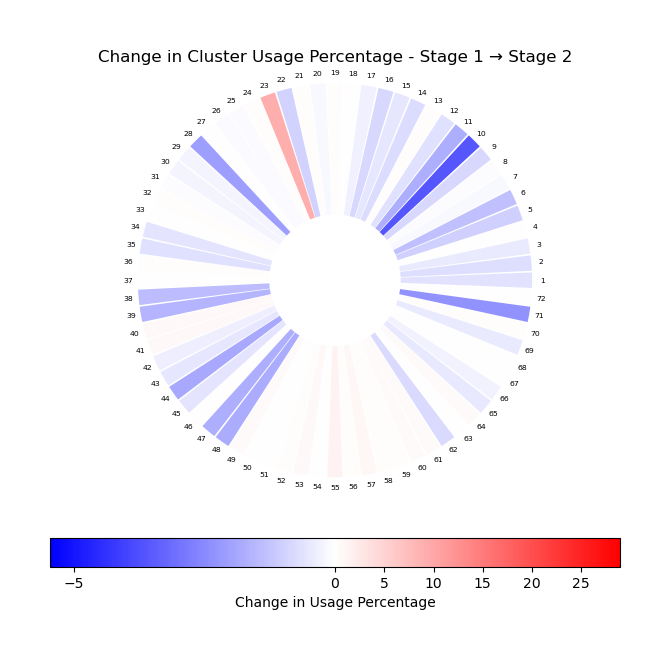

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_usage_map\eps\2mp_stage1_to_stage3.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_usage_map\png\2mp_stage1_to_stage3.png


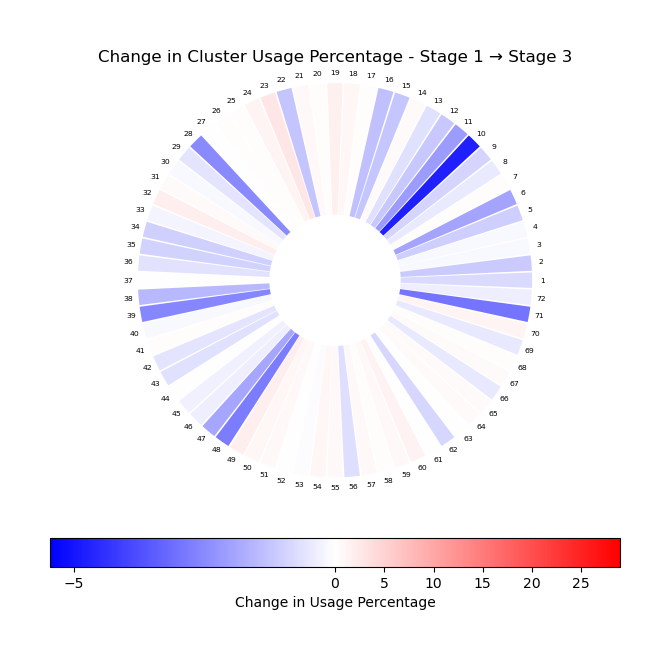

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_usage_map\eps\2mp_stage1_to_stage4.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_usage_map\png\2mp_stage1_to_stage4.png


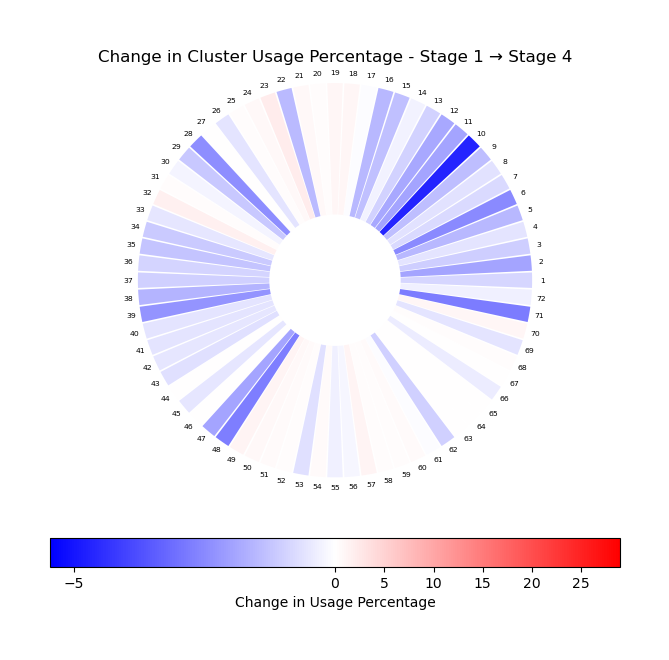

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_usage_map\eps\2mp_stage1_to_stage5.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_usage_map\png\2mp_stage1_to_stage5.png


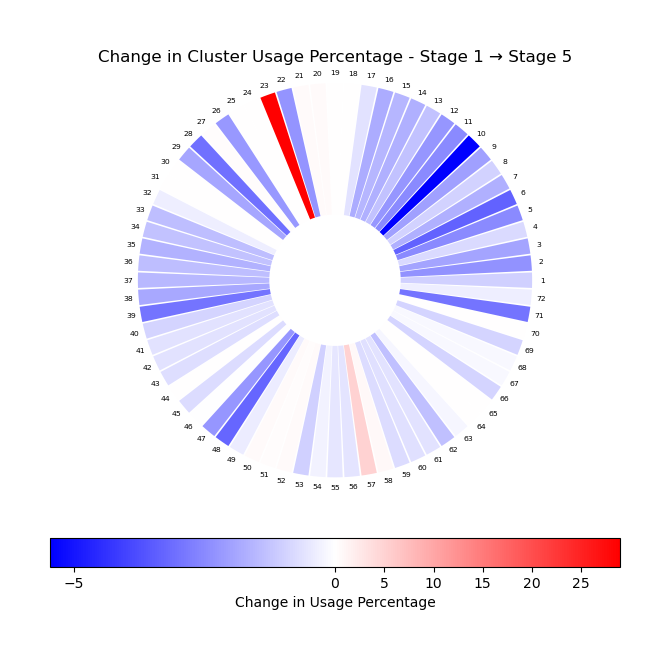

Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_usage_map\csv\cluster_usage_change_stage1_to_stage2.csv
Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_usage_map\csv\cluster_usage_change_stage1_to_stage3.csv
Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_usage_map\csv\cluster_usage_change_stage1_to_stage4.csv
Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_usage_map\csv\cluster_usage_change_stage1_to_stage5.csv


In [128]:
plot_cluster_usage_map( stage_dfs )

t-SNE

In [129]:
# 1. Master t-SNE plot (all data, colored consistently)
fig_all = px.scatter(
    combined_matrix,
    x='TSNE-1', y='TSNE-2',
    color=combined_matrix['Cluster'].astype(str),
    color_discrete_map=cluster_to_color,
    hover_name=combined_matrix['Cluster'].astype(str),
    labels={'color': 'Cluster'},
    title='t-SNE of All Data'
)
fig_all.update_traces(marker=dict(size=7, line=dict(width=0.5, color='DarkSlateGrey')))
fig_all.update_layout(
    legend_title='Cluster',
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)

x_range = fig_all.layout.xaxis.range # Capture axis ranges from master plot
y_range = fig_all.layout.yaxis.range

png_dir = os.path.join( output_dir , r'tSNE\png' )
os.makedirs(png_dir, exist_ok=True)
png_dir_all = os.path.join(png_dir, f"tSNE_all")

svg_dir = os.path.join( output_dir , r'tSNE\svg' )
os.makedirs(svg_dir, exist_ok=True)
svg_dir_all = os.path.join(svg_dir, f"tSNE_all")

pio.write_image(fig_all, png_dir_all + ".png", width=1000, height=1000)
pio.write_image(fig_all, svg_dir_all + ".svg", width=1000, height=1000)
print(f"Saved: {png_dir_all}")
print(f"Saved: {svg_dir_all}")

fig_all.show() 

Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\tSNE\png\tSNE_all
Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\tSNE\svg\tSNE_all


In [ ]:
# CORRECT THIS - combined_matrix['Week_Number'] and weeks aren't matching

# 2-6. Per-experiment type t-SNE plots, always using the full color map
for exp_type, exp_label in zip(weeks, stage_names):
    combined_matrix_exp = combined_matrix[combined_matrix['Week_Number'] == exp_type].copy()
    if combined_matrix_exp.empty:
        continue
    fig = px.scatter(
        combined_matrix_exp,
        x='TSNE-1', y='TSNE-2',
        color=combined_matrix_exp['Cluster'].astype(str),
        color_discrete_map=cluster_to_color,
        category_orders={'Cluster': cluster_labels_str},
        hover_name=combined_matrix_exp['Cluster'].astype(str),
        labels={'color': 'Cluster'},
        title=f't-SNE: {exp_label}'
    )
    fig.update_traces(marker=dict(size=7, line=dict(width=0.5, color='DarkSlateGrey')))
    fig.update_layout(
        legend_title='Cluster',
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(showgrid=False, range=x_range),
        yaxis=dict(showgrid=False, range=y_range)
    )

    png_dir_individual = os.path.join(png_dir, f"tSNE_{exp_label}")
    svg_dir_individual = os.path.join(svg_dir, f"tSNE_{exp_label}")
    
    pio.write_image(fig, png_dir_individual + ".png", width=1000, height=1000)
    pio.write_image(fig, svg_dir_individual + ".svg", width=1000, height=1000)
    print(f"Saved: {png_dir_individual}")
    print(f"Saved: {svg_dir_individual}")


    fig.show()

Cluster Level Char

Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\bout_duration\png\cluster_percent_usage.png
Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\bout_duration\eps\cluster_percent_usage.eps


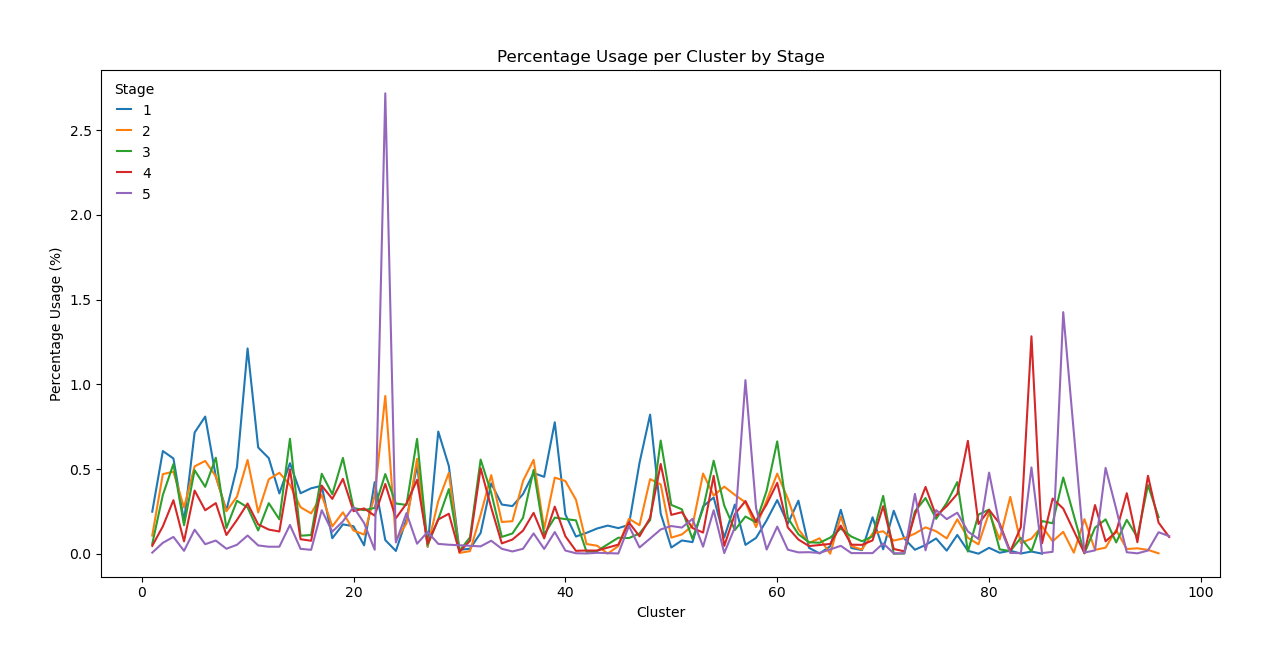

In [131]:
bout_duration_df = extract_bouts(combined_matrix)
bout_duration_df = bout_duration_df[bout_duration_df['duration'] > 0] #Duration must be positive
bout_duration_df['Week_Number'] = bout_duration_df['Week_Number'].fillna(0).astype(int)
bout_duration_df = bout_duration_df[bout_duration_df['Week_Number'] != 0]

grouped_bout_duration = bout_duration_df.groupby(['Cluster', 'Week_Number'], as_index=False)['duration'].sum()
total_duration = grouped_bout_duration['duration'].sum()
grouped_bout_duration['percentage_usage'] = grouped_bout_duration['duration'] / total_duration * 100

# Cluster Usage (Bout Duration) Percentage
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=grouped_bout_duration,
    x="Cluster",
    y="percentage_usage",
    hue="Week_Number",
    palette="tab10",
    linewidth=1.5
)

plt.title("Percentage Usage per Cluster by Stage")
plt.xlabel("Cluster")
plt.ylabel("Percentage Usage (%)")
plt.legend(title="Stage")
plt.tight_layout()

png_dir = os.path.join(output_dir, 'cluster_level_char', 'bout_duration', 'png')
os.makedirs(png_dir, exist_ok=True)
eps_dir = os.path.join(output_dir, 'cluster_level_char', 'bout_duration', 'eps')
os.makedirs(eps_dir, exist_ok=True)

png_path = os.path.join(png_dir, "cluster_percent_usage.png")
plt.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "cluster_percent_usage.eps")
plt.savefig(eps_path)
print(f"Saved: {eps_path}")

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\bout_duration\png\cluster_percent_usage_ordered.png
Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\bout_duration\eps\cluster_percent_usage_ordered.eps


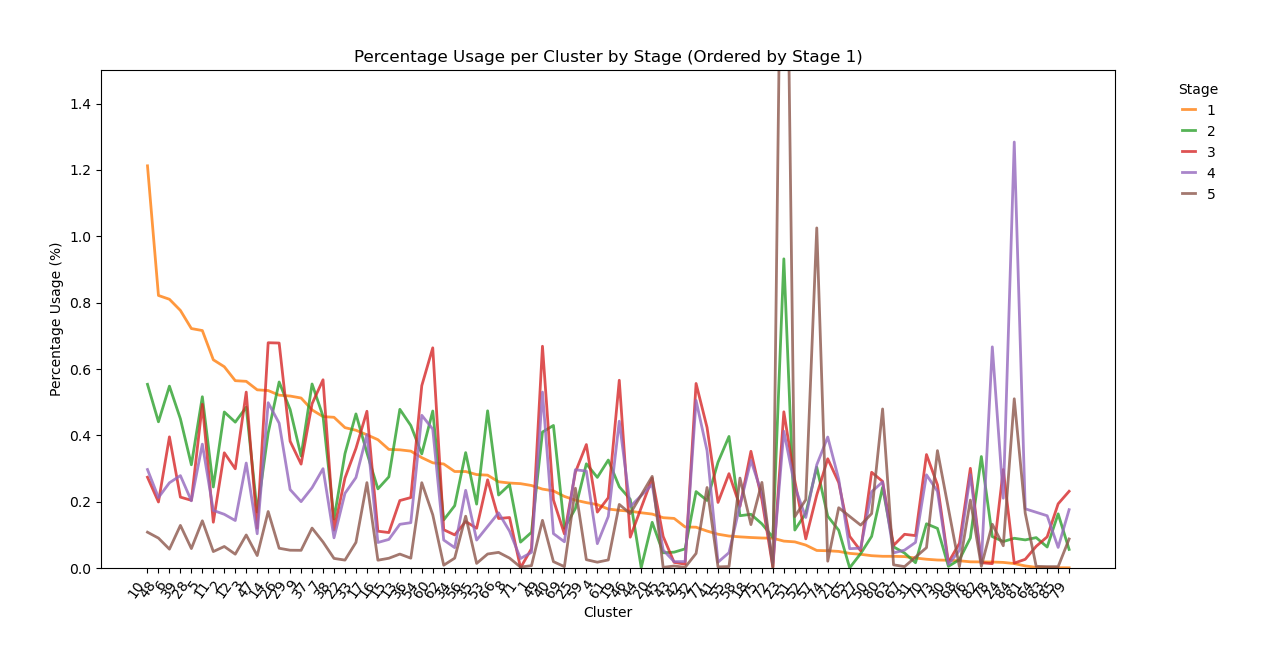

In [132]:
# Ordering clusters by Stage 1 usage
stage1_order = grouped_bout_duration[grouped_bout_duration['Week_Number'] == 1]
stage1_order = stage1_order.sort_values('percentage_usage', ascending=False)['Cluster']

grouped_bout_duration['Cluster'] = pd.Categorical(
    grouped_bout_duration['Cluster'],
    categories=stage1_order,
    ordered=True
)

grouped_bout_duration.dropna(inplace=True)

# Plotting Percentage usage per cluster by stage (ordered by 1)
plt.figure(figsize=(12, 6))

for week, group_data in grouped_bout_duration.groupby('Week_Number'):
    group_sorted = group_data.sort_values('Cluster')
    x_vals = group_sorted['Cluster'].cat.codes
    
    plt.plot(
        x_vals,
        group_sorted['percentage_usage'],
        label=f"{week}",
        linestyle='-',
        linewidth=2,
        alpha=0.8,
        color=plt.cm.tab10(week % 10)
    )

plt.ylim(0, 1.5)

plt.xticks(
    ticks=range(len(grouped_bout_duration['Cluster'].cat.categories)),
    labels=grouped_bout_duration['Cluster'].cat.categories,
    rotation=55, ha='right'
)

plt.title("Percentage Usage per Cluster by Stage (Ordered by Stage 1)")
plt.xlabel("Cluster")
plt.ylabel("Percentage Usage (%)")
plt.legend(title="Stage", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

png_path = os.path.join(png_dir, "cluster_percent_usage_ordered.png")
plt.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "cluster_percent_usage_ordered.eps")
plt.savefig(eps_path)
print(f"Saved: {eps_path}")

plt.show()


Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\bout_duration\png\average_bout_duration.png
Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\bout_duration\eps\average_bout_duration.eps


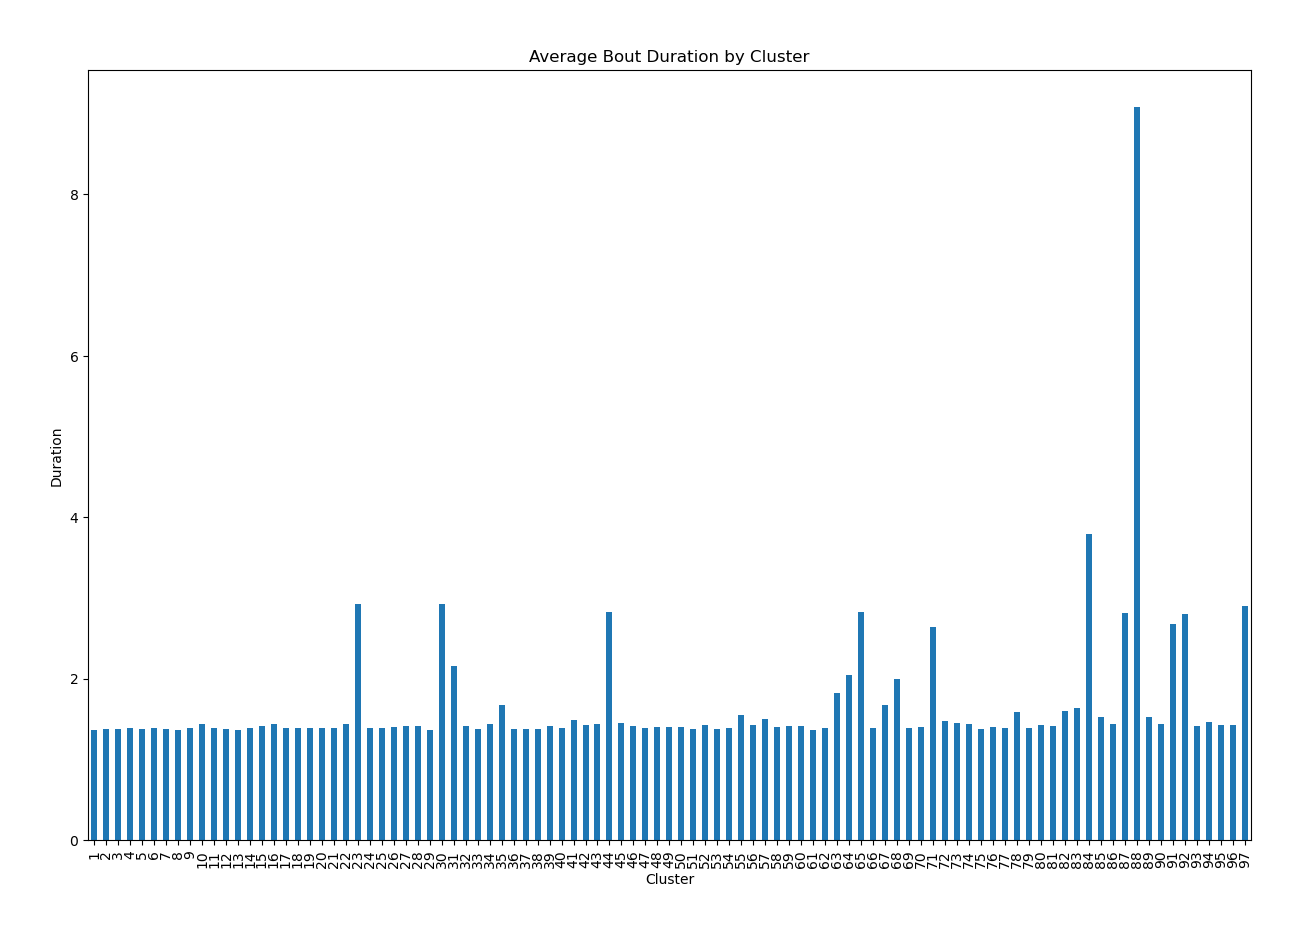

In [133]:
avg_bout_duration_df = bout_duration_df.groupby("Cluster")["duration"].mean()
ax = avg_bout_duration_df.plot(kind="bar", title="Average Bout Duration by Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Duration")

png_path = os.path.join(png_dir, "average_bout_duration.png")
ax.figure.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "average_bout_duration.eps")
ax.figure.savefig(eps_path)
print(f"Saved: {eps_path}")

Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\bout_duration\png\median_bout_duration.png
Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\bout_duration\eps\median_bout_duration.eps


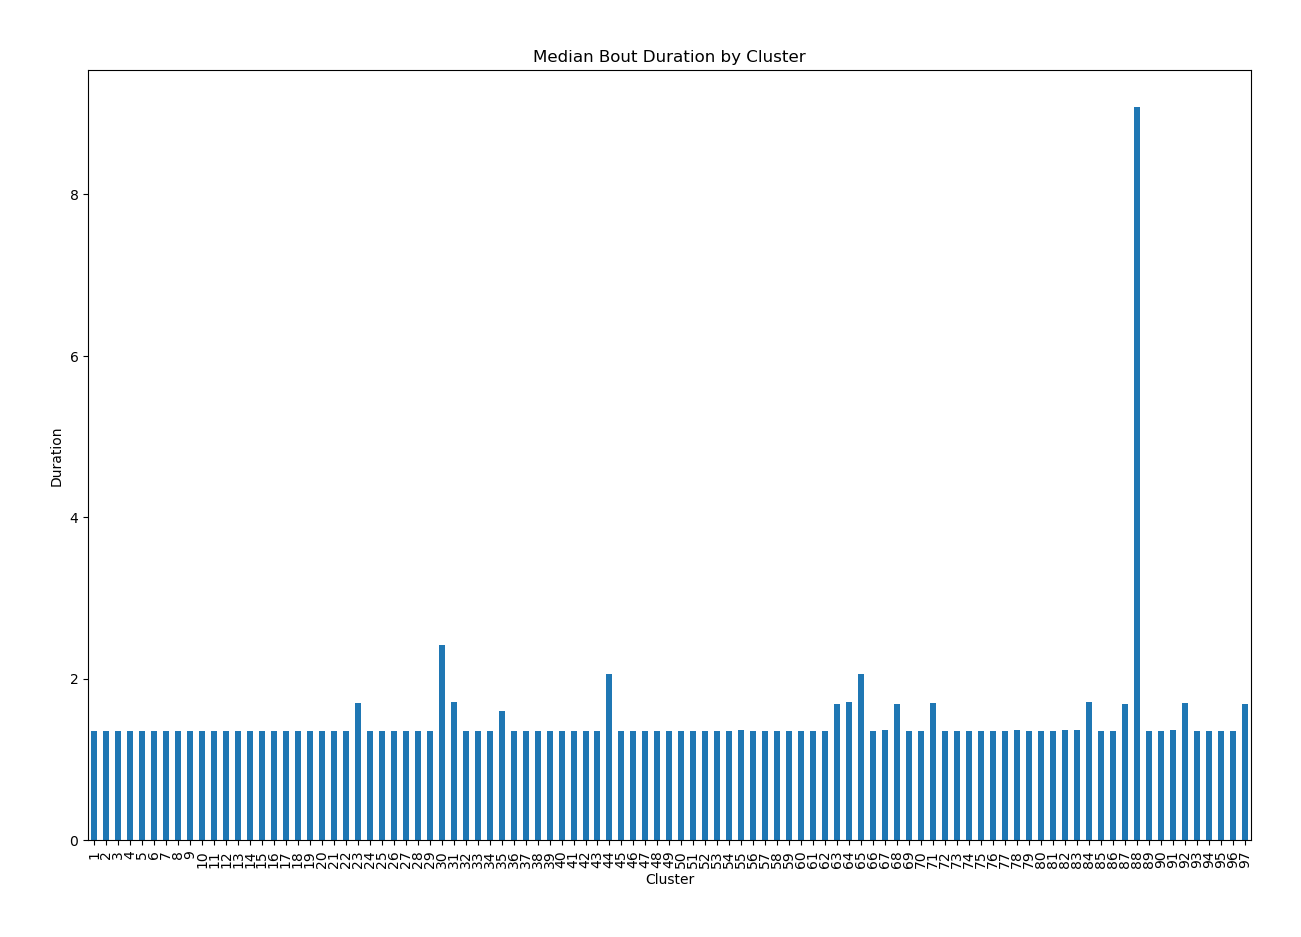

In [134]:
med_bout_duration_df = bout_duration_df.groupby("Cluster")["duration"].median()
ax = med_bout_duration_df.plot(kind="bar", title="Median Bout Duration by Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Duration")

png_path = os.path.join(png_dir, "median_bout_duration.png")
ax.figure.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "median_bout_duration.eps")
ax.figure.savefig(eps_path)
print(f"Saved: {eps_path}")

Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\bout_duration\png\avg_bout_duration_by_stage.png
Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\bout_duration\eps\avg_bout_duration_by_stage.eps


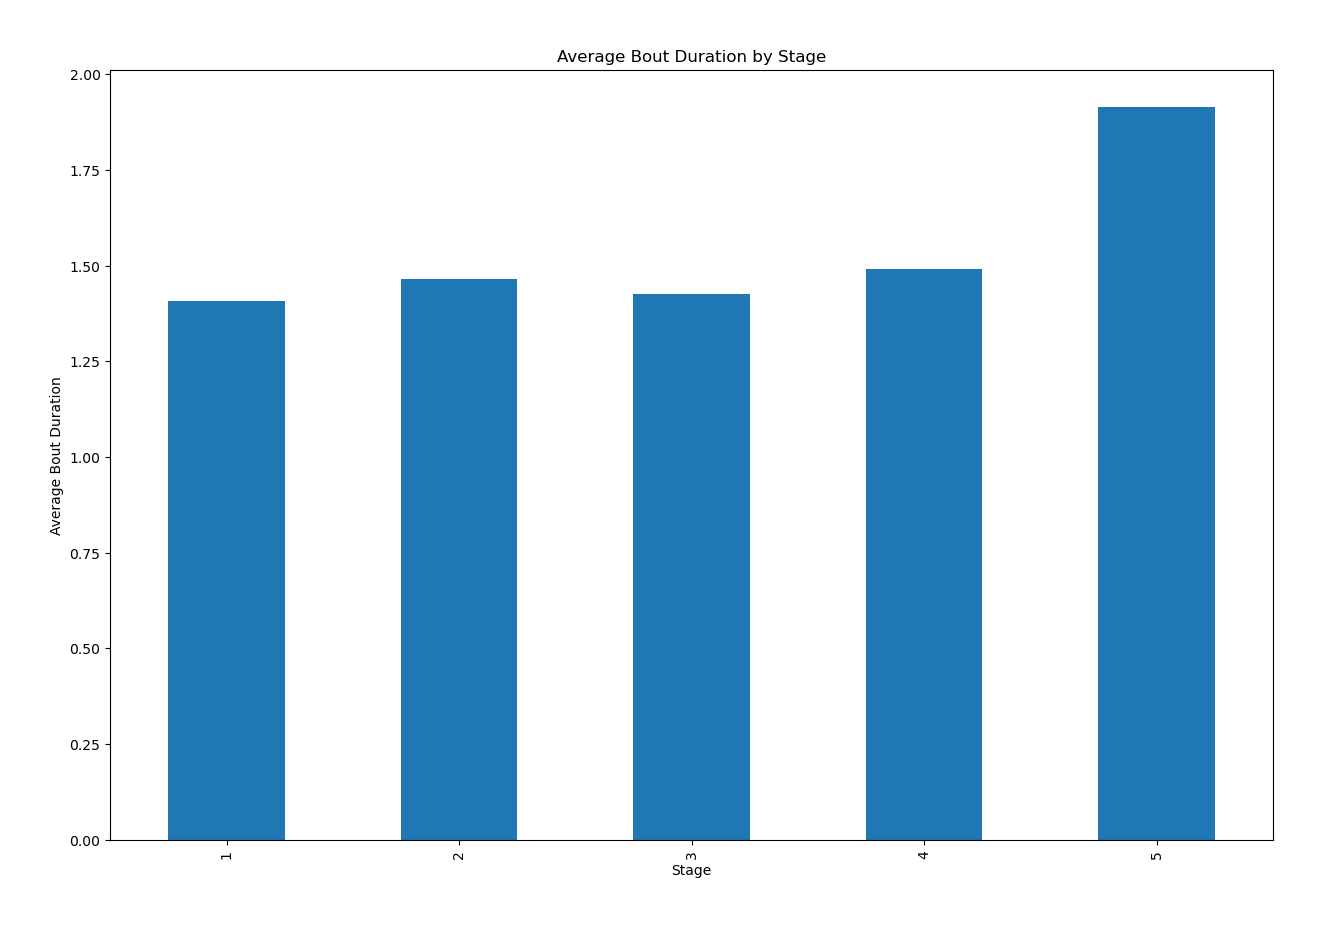

In [135]:
avg_bout_duration_by_week = bout_duration_df.groupby("Week_Number")["duration"].mean()

ax = avg_bout_duration_by_week.plot(
    kind="bar",
    title="Average Bout Duration by Stage",
    figsize=(15, 10),
    xlabel="Stage",
    ylabel="Average Bout Duration"
)

png_path = os.path.join(png_dir, "avg_bout_duration_by_stage.png")
ax.figure.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "avg_bout_duration_by_stage.eps")
ax.figure.savefig(eps_path)
print(f"Saved: {eps_path}")

Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\bout_duration\png\bout_duration_heatmap.png
Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\bout_duration\eps\bout_duration_heatmap.eps


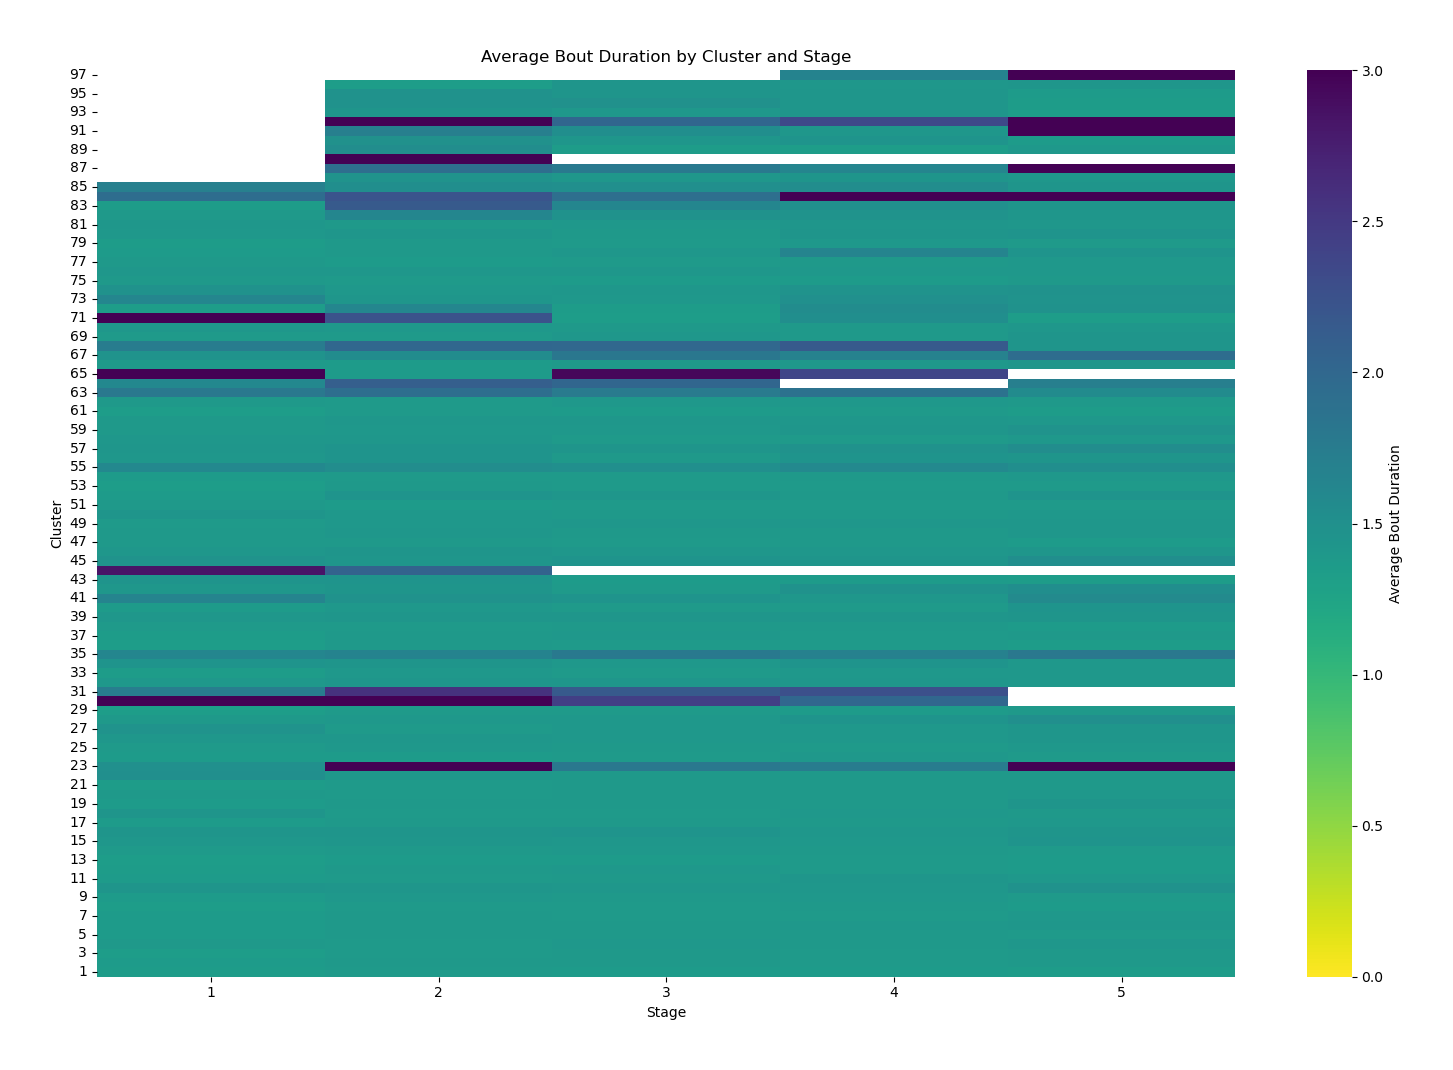

In [136]:
pivot_df = bout_duration_df.groupby(['Cluster', 'Week_Number'])['duration'].mean().unstack()

plt.figure(figsize=(15, 10))
ax = sns.heatmap(
    pivot_df,
    cmap='viridis_r',
    vmin=0, vmax=3,
    cbar_kws={'label': 'Average Bout Duration'}
)

ax.invert_yaxis()

plt.title('Average Bout Duration by Cluster and Stage')
plt.xlabel('Stage')
plt.ylabel('Cluster')
plt.tight_layout()

png_path = os.path.join(png_dir, "bout_duration_heatmap.png")
plt.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "bout_duration_heatmap.eps")
plt.savefig(eps_path)
print(f"Saved: {eps_path}")

plt.show()

In [137]:
csv_dir = os.path.join( output_dir , r'cluster_level_char\bout_duration\csv' )
os.makedirs(csv_dir, exist_ok=True)

save_path = os.path.join(csv_dir, f"bout_duration_{mouse_name}.csv")
bout_duration_df.to_csv(save_path, index=False)
print(f"Saved: {save_path}")

Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\bout_duration\csv\bout_duration_2mp.csv


In [138]:
## RECURRENCE INTERVAL
# How much time it takes for clusters to reappear

In [139]:
# Recurrence Time Calculation
recurrence_time_df = bout_duration_df.sort_values(by=['Cluster', 'start_timestamp']).copy()
recurrence_time_df['recurrence_time'] = recurrence_time_df.groupby('Cluster')['start_timestamp'].diff()
recurrence_time_df_filtered = recurrence_time_df.dropna(subset=['recurrence_time'])

Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\recurrence_interval\png\avg_recurrence_interval.png
Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\recurrence_interval\eps\avg_recurrence_interval.eps


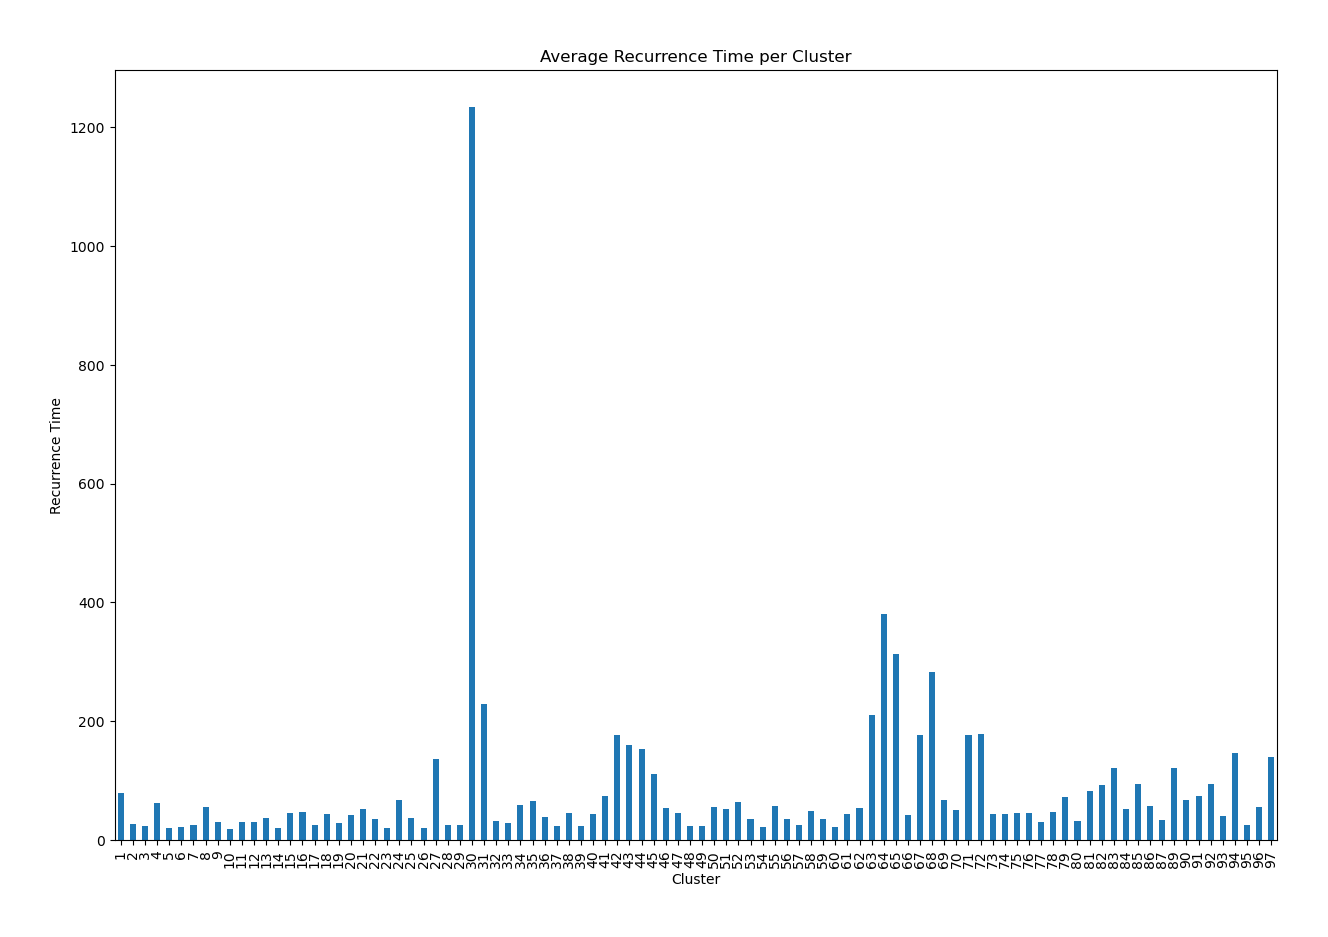

In [140]:
# Mean Recurrence Time Graph
avg_recurrence_time = recurrence_time_df_filtered.groupby("Cluster")["recurrence_time"].mean()
ax = avg_recurrence_time.plot(kind="bar", title="Average Recurrence Time per Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Recurrence Time")

png_dir = os.path.join(output_dir, 'cluster_level_char', 'recurrence_interval', 'png')
os.makedirs(png_dir, exist_ok=True)
eps_dir = os.path.join(output_dir, 'cluster_level_char', 'recurrence_interval', 'eps')
os.makedirs(eps_dir, exist_ok=True)

png_path = os.path.join(png_dir, "avg_recurrence_interval.png")
ax.figure.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "avg_recurrence_interval.eps")
ax.figure.savefig(eps_path)
print(f"Saved: {eps_path}")

Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\recurrence_interval\png\median_recurrence_interval.png
Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\recurrence_interval\eps\median_recurrence_interval.eps


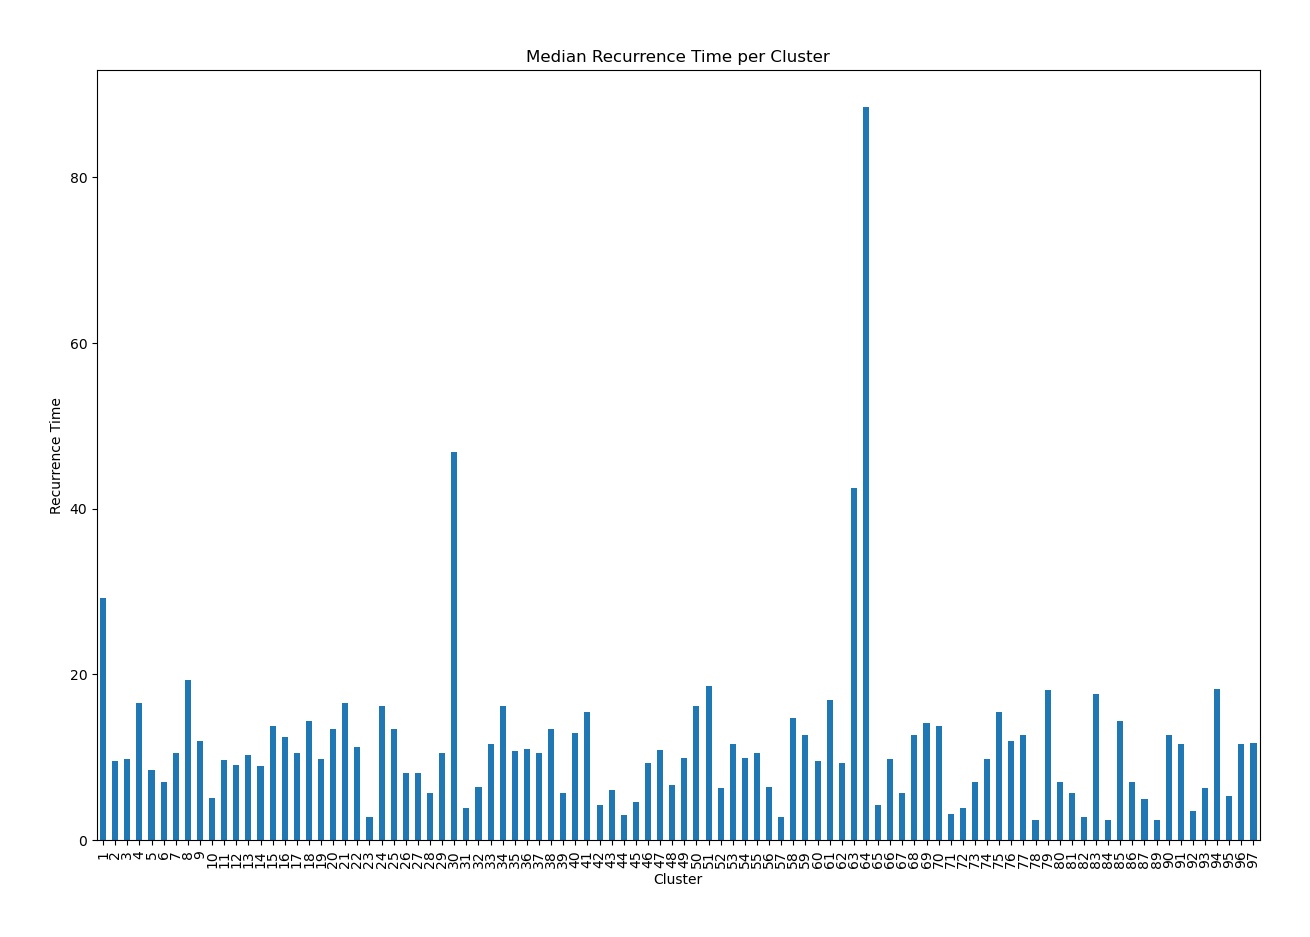

In [141]:
# Median Recurrence Time Graph
med_recurrence_time = recurrence_time_df_filtered.groupby("Cluster")["recurrence_time"].median()
ax = med_recurrence_time.plot(kind="bar", title="Median Recurrence Time per Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Recurrence Time")

png_path = os.path.join(png_dir, "median_recurrence_interval.png")
ax.figure.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "median_recurrence_interval.eps")
ax.figure.savefig(eps_path)
print(f"Saved: {eps_path}")

Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\recurrence_interval\png\avg_recurrence_interval_by_stage.png
Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\recurrence_interval\eps\avg_recurrence_interval_by_stage.eps


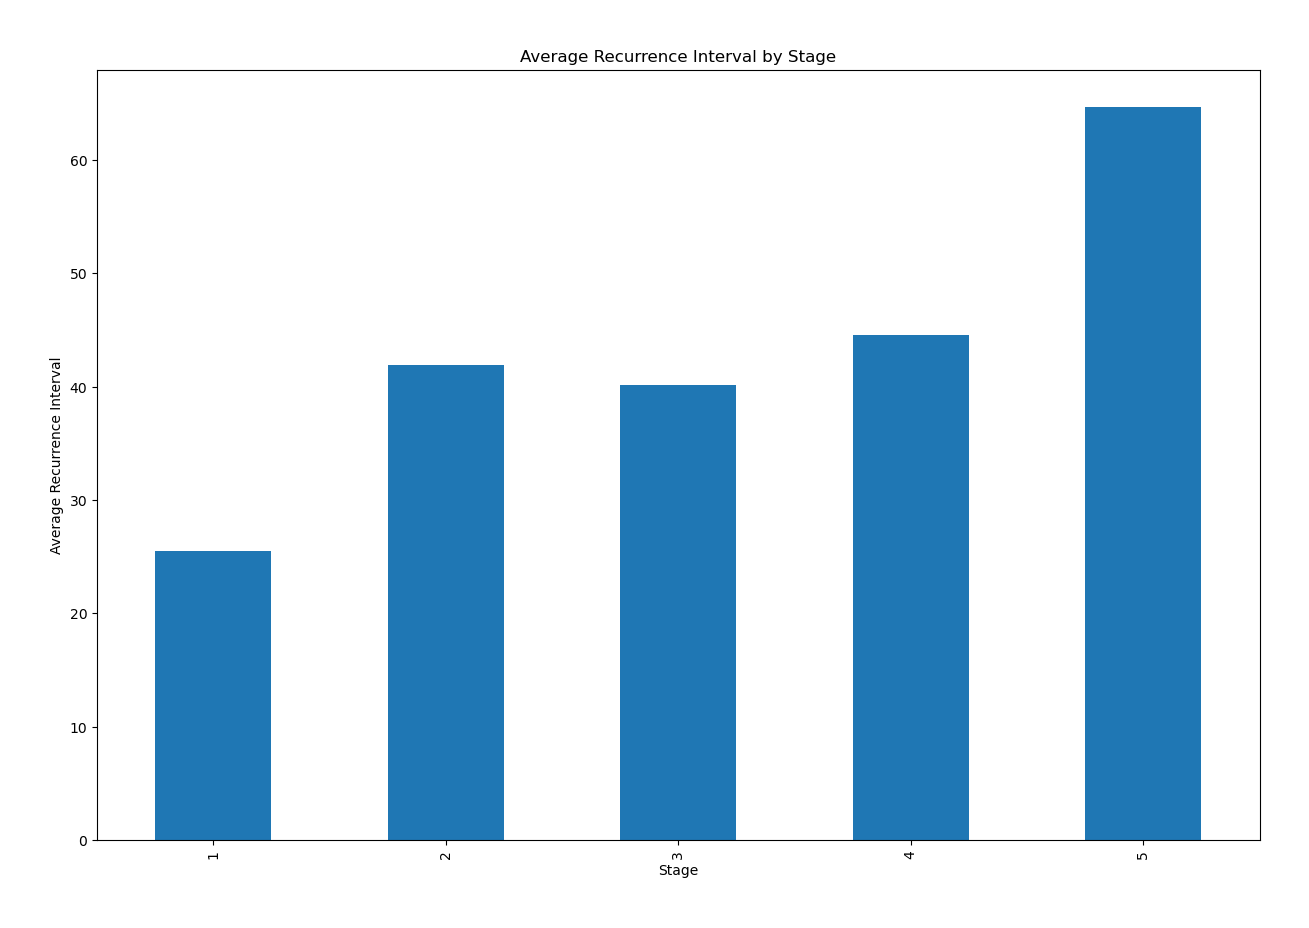

In [142]:
avg_recurrence_duration_by_week = recurrence_time_df_filtered.groupby("Week_Number")["recurrence_time"].mean()

ax = avg_recurrence_duration_by_week.plot(
    kind="bar",
    title="Average Recurrence Interval by Stage",
    figsize=(15, 10),
    xlabel="Stage",
    ylabel="Average Recurrence Interval"
)

png_path = os.path.join(png_dir, "avg_recurrence_interval_by_stage.png")
ax.figure.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "avg_recurrence_interval_by_stage.eps")
ax.figure.savefig(eps_path)
print(f"Saved: {eps_path}")

Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\recurrence_interval\png\recurrence_interval_heatmap.png
Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\recurrence_interval\eps\recurrence_interval_heatmap.eps


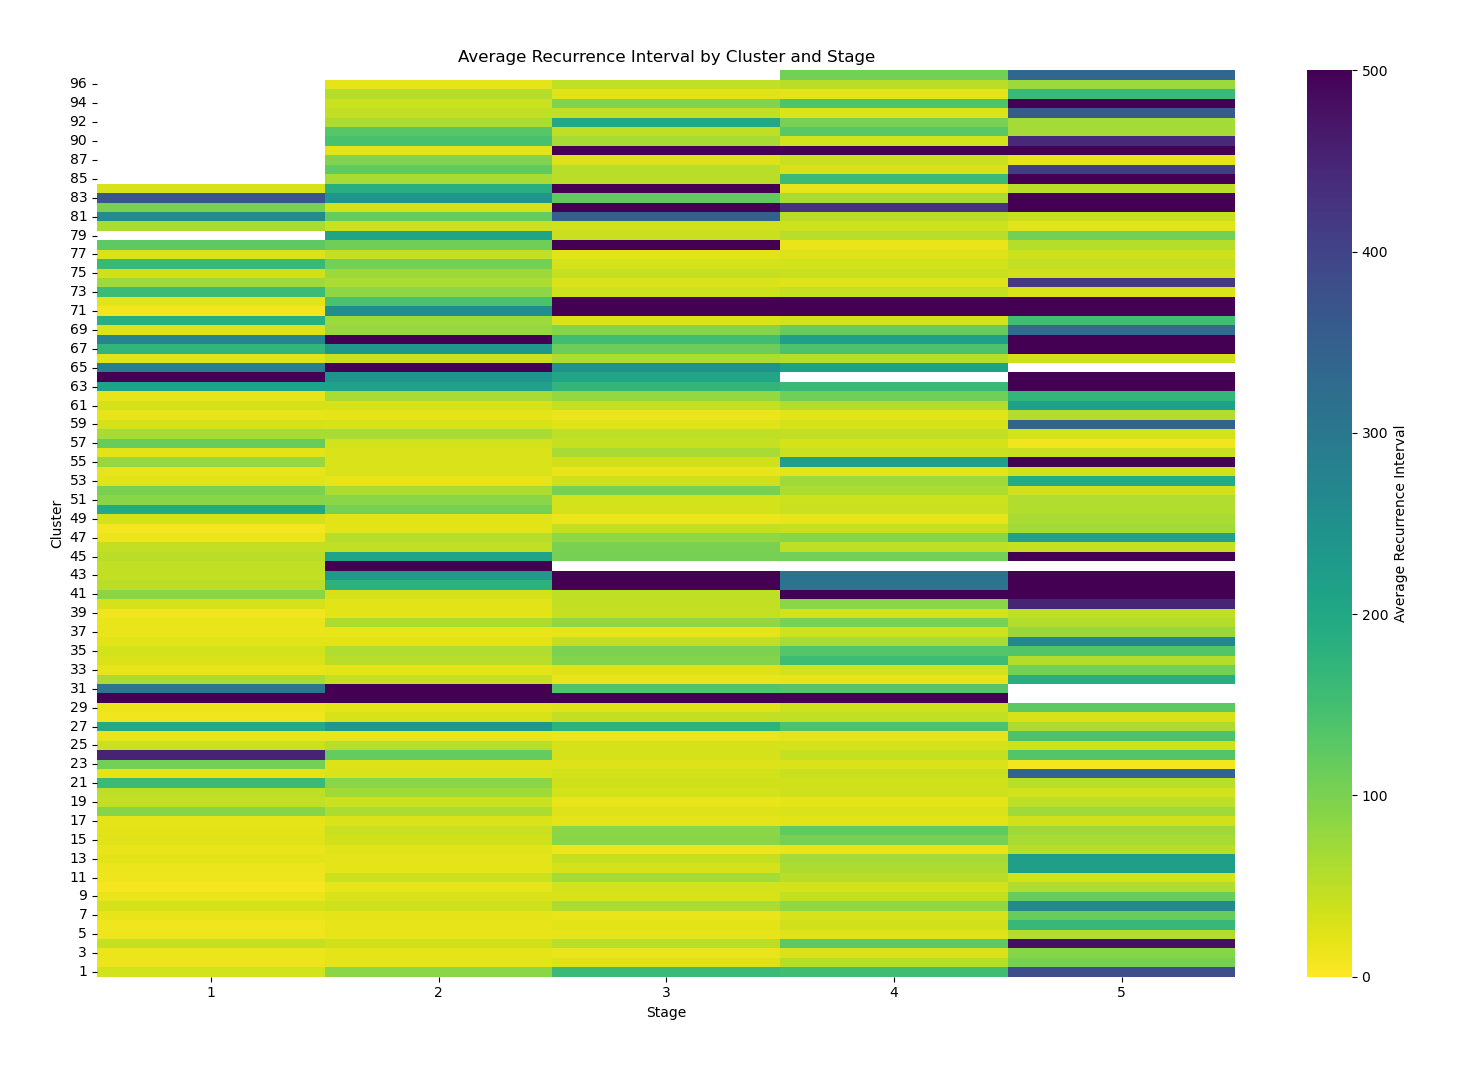

In [143]:
pivot_df = recurrence_time_df_filtered.groupby(['Cluster', 'Week_Number'])['recurrence_time'].mean().unstack()

plt.figure(figsize=(15, 10))
ax = sns.heatmap(
    pivot_df,
    cmap='viridis_r',
    vmin=0, vmax=500,
    cbar_kws={'label': 'Average Recurrence Interval'}
)
ax.invert_yaxis()

plt.title('Average Recurrence Interval by Cluster and Stage')
plt.xlabel('Stage')
plt.ylabel('Cluster')
plt.tight_layout()

png_path = os.path.join(png_dir, "recurrence_interval_heatmap.png")
plt.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "recurrence_interval_heatmap.eps")
plt.savefig(eps_path)
print(f"Saved: {eps_path}")

plt.show()

In [144]:
csv_dir = os.path.join( output_dir , r'cluster_level_char\recurrence_interval\csv' )
os.makedirs(csv_dir, exist_ok=True)

save_path = os.path.join(csv_dir, f"recurrence_interval_{mouse_name}.csv")
recurrence_time_df_filtered.to_csv(save_path, index=False)
print(f"Saved: {save_path}")

Saved: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\cluster_level_char\recurrence_interval\csv\recurrence_interval_2mp.csv


Sankey with Pie Plots


--- Incoming and Outgoing Flow Counts for Week 1 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week1_incoming.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week1_incoming.png


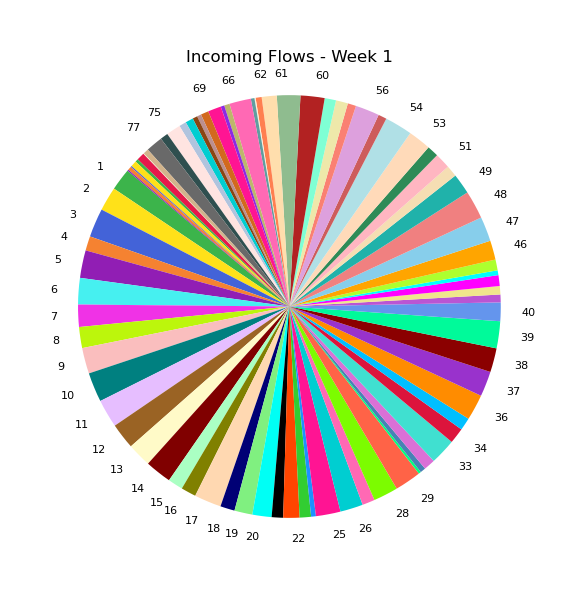

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week1_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week1_outgoing.png


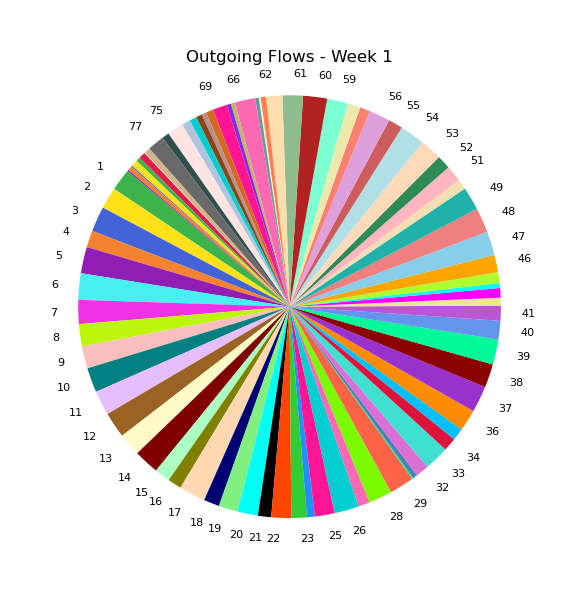


--- Incoming and Outgoing Flow Counts for Week 2 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week2_incoming.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week2_incoming.png


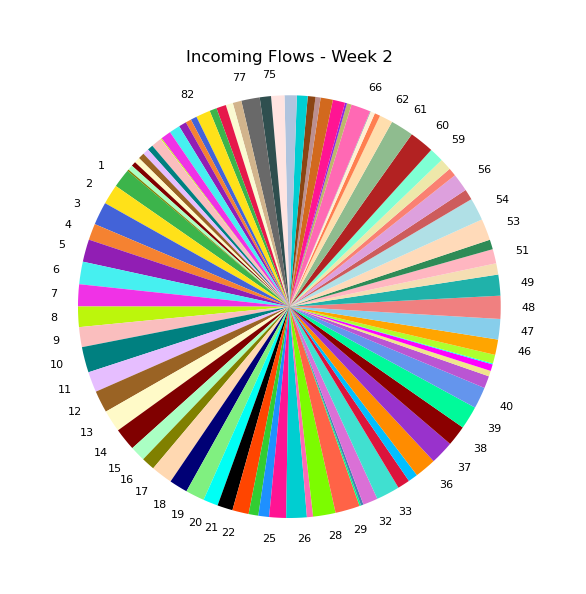

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week2_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week2_outgoing.png


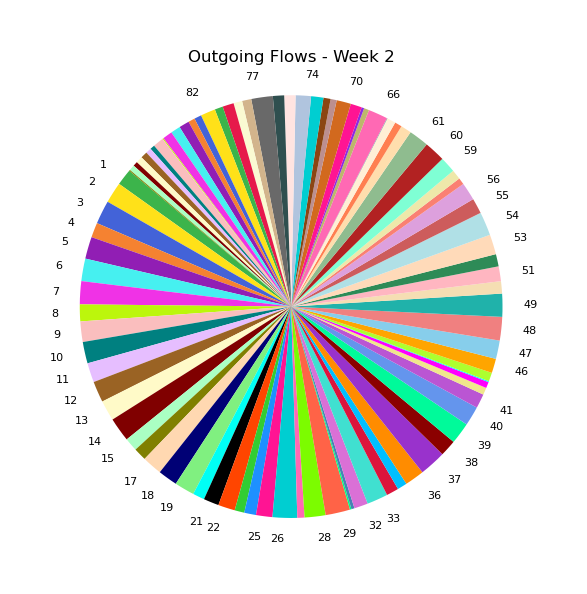


--- Incoming and Outgoing Flow Counts for Week 3 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week3_incoming.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week3_incoming.png


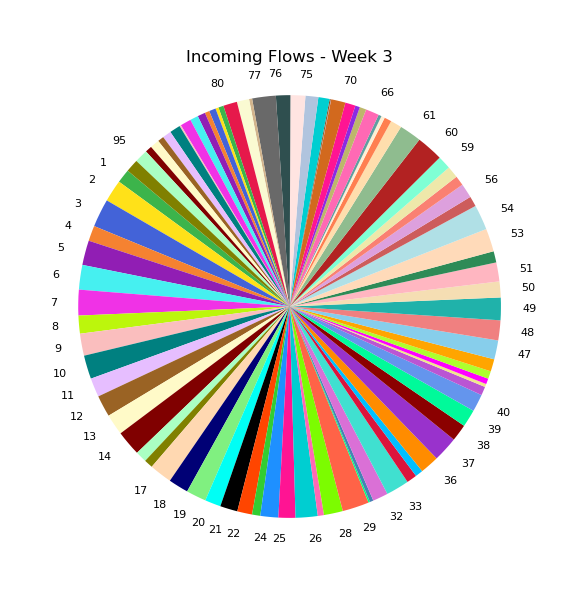

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week3_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week3_outgoing.png


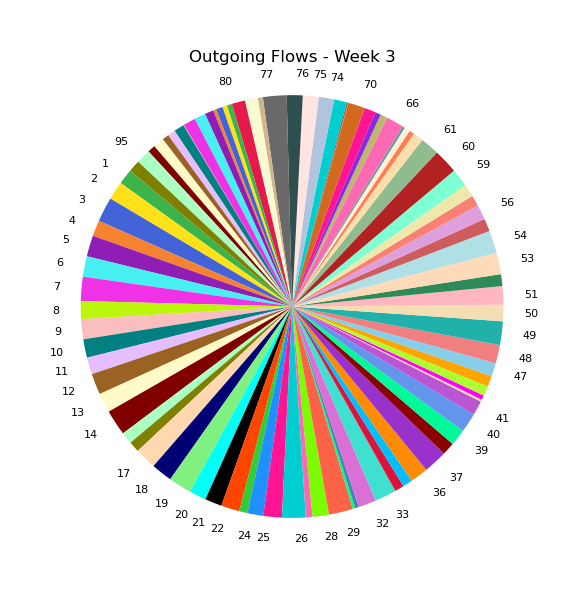


--- Incoming and Outgoing Flow Counts for Week 4 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week4_incoming.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week4_incoming.png


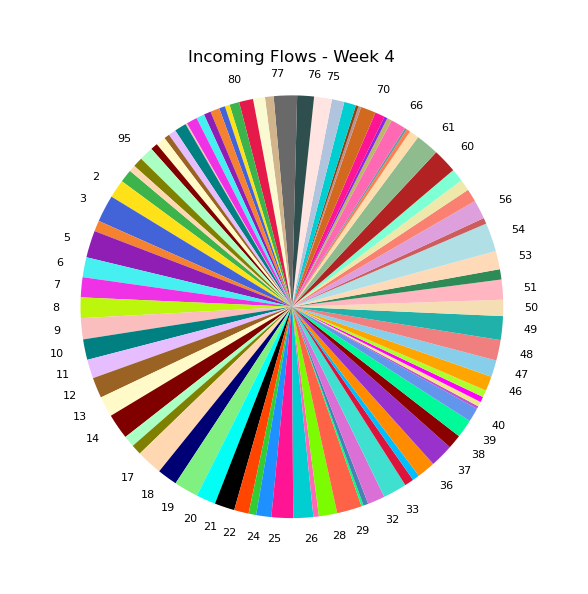

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week4_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week4_outgoing.png


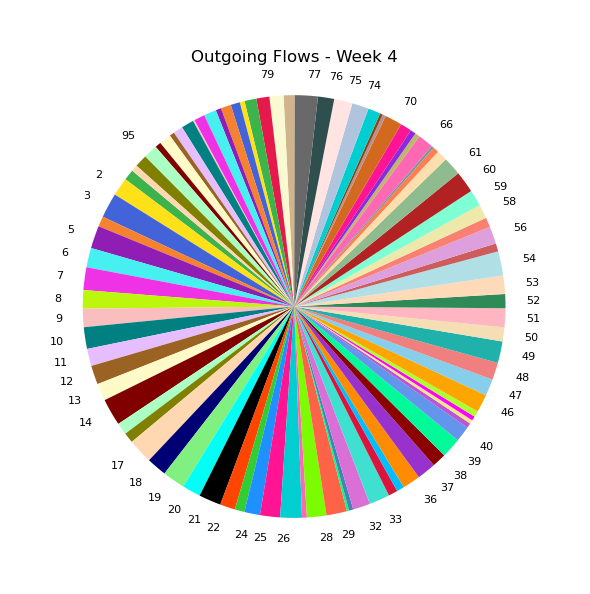


--- Incoming and Outgoing Flow Counts for Week 5 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week5_incoming.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week5_incoming.png


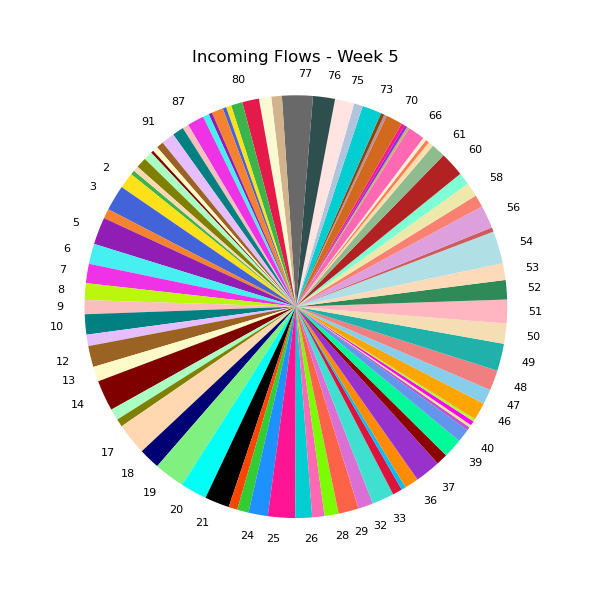

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week5_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week5_outgoing.png


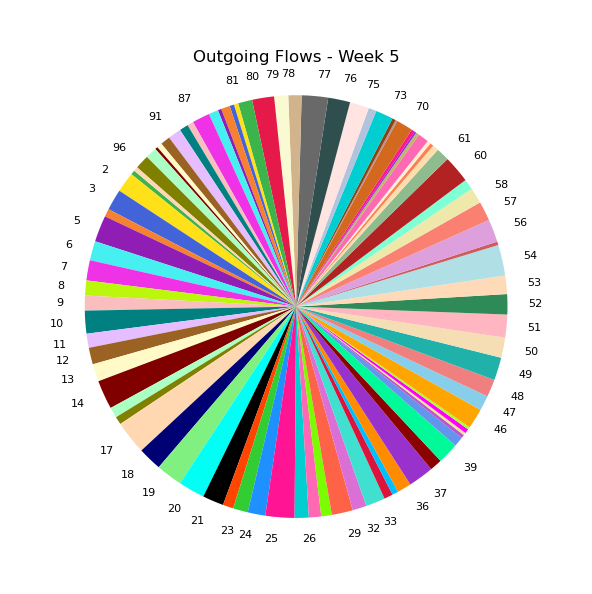


--- Incoming and Outgoing Flow Counts for Week All ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_weekAll_incoming.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_weekAll_incoming.png


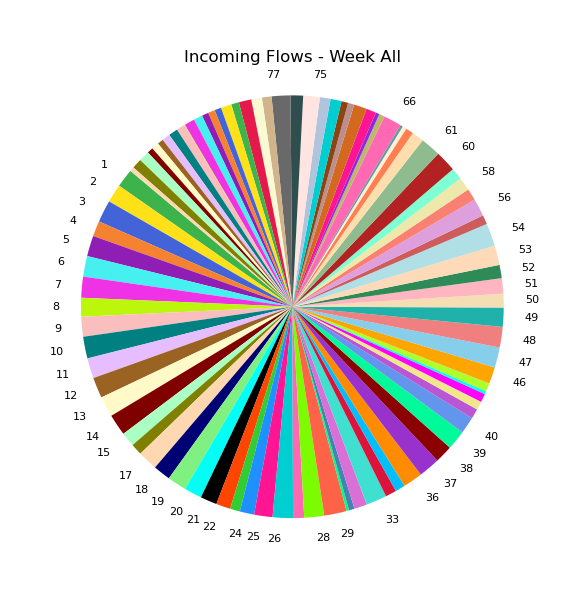

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_weekAll_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_weekAll_outgoing.png


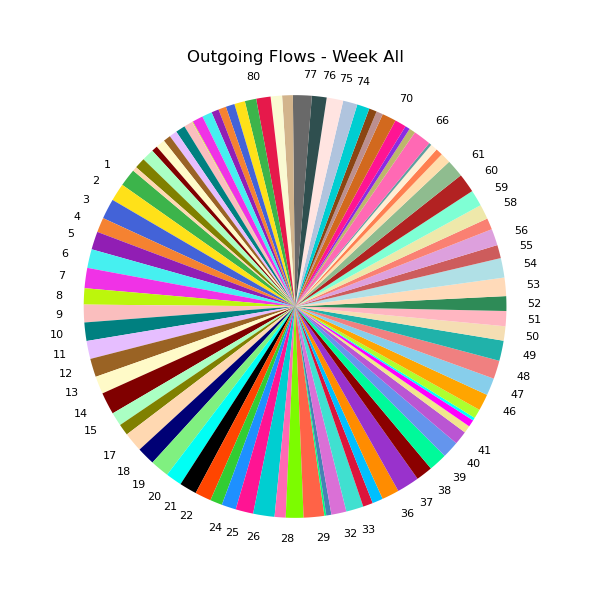

In [145]:
# Pie Flow Chart
for week_number in week_numbers:
    arena_data = all_data[all_data['Week_Number'] == week_number]
    create_sankey_and_pies(
        arena_data,
        week_number,
        mouse_name=mouse_name
    )

create_sankey_and_pies(all_data, "All", mouse_name=mouse_name)

In [146]:
# Sankeys Grouped
for week in week_numbers:
    arena_data = all_data[all_data['Week_Number'] == week_number]
    create_grouped_sankey_plot(
        arena_data,
        week,
        mouse_name=mouse_name
    )

create_grouped_sankey_plot(
    all_data,
    "All",
    mouse_name=mouse_name
)

SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\sankey_2mp_stage1.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\sankey_2mp_stage1.png
SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\sankey_2mp_stage2.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\sankey_2mp_stage2.png
SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\sankey_2mp_stage3.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\sankey_2mp_stage3.png
SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\sankey_2mp_stage4.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\sankey

--- Group Flow Counts for Week 1 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week1_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week1_incoming_grouped.png


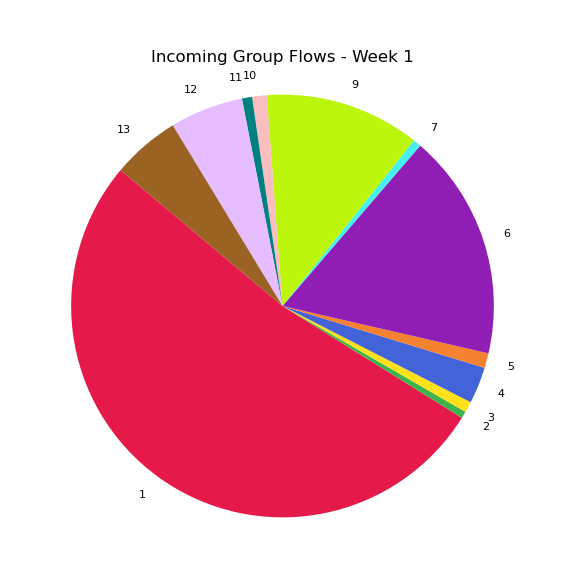

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week1_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week1_outgoing_grouped.png


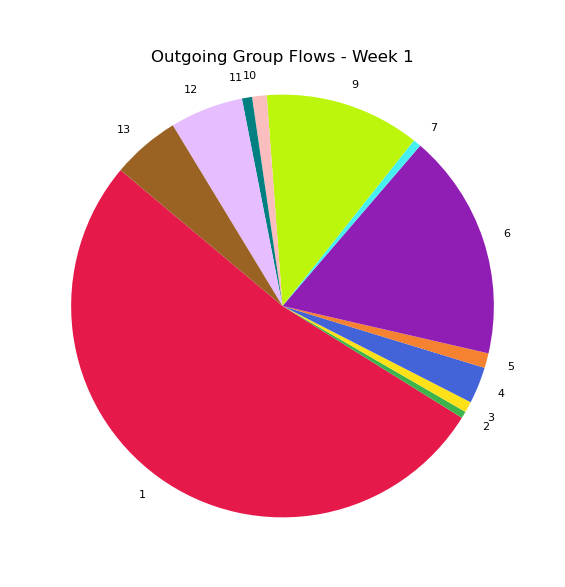

--- Group Flow Counts for Week 2 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week2_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week2_incoming_grouped.png


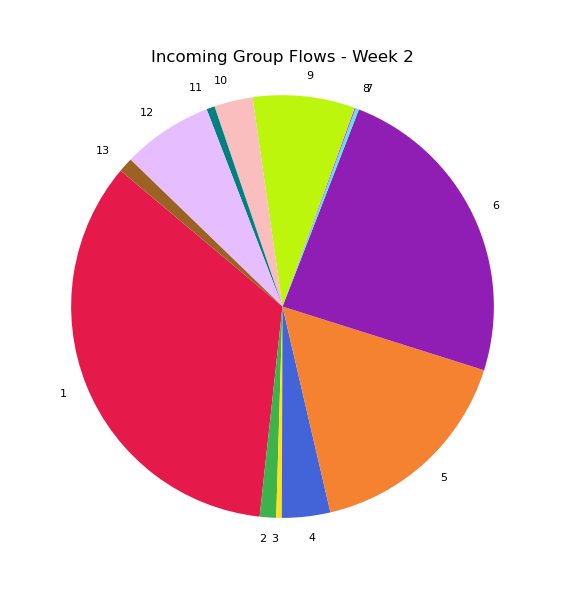

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week2_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week2_outgoing_grouped.png


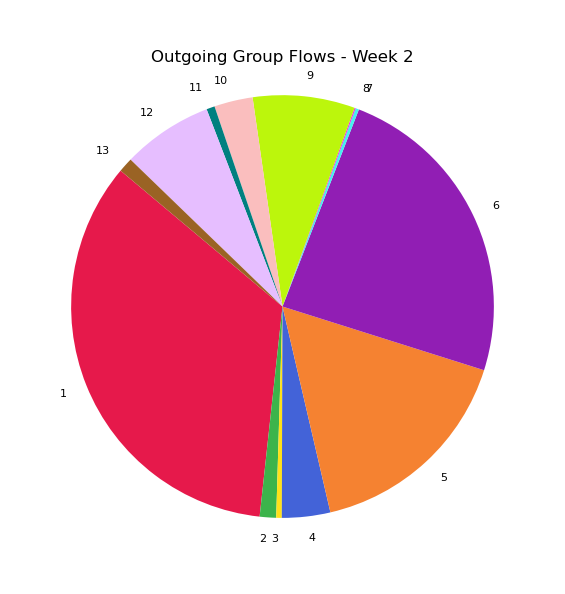

--- Group Flow Counts for Week 3 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week3_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week3_incoming_grouped.png


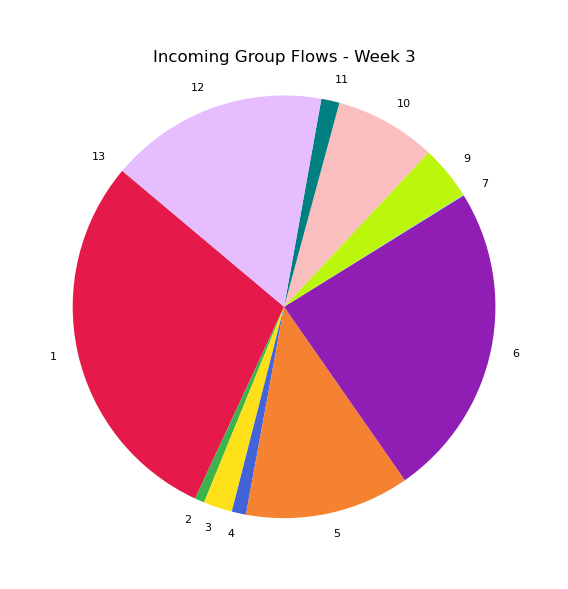

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week3_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week3_outgoing_grouped.png


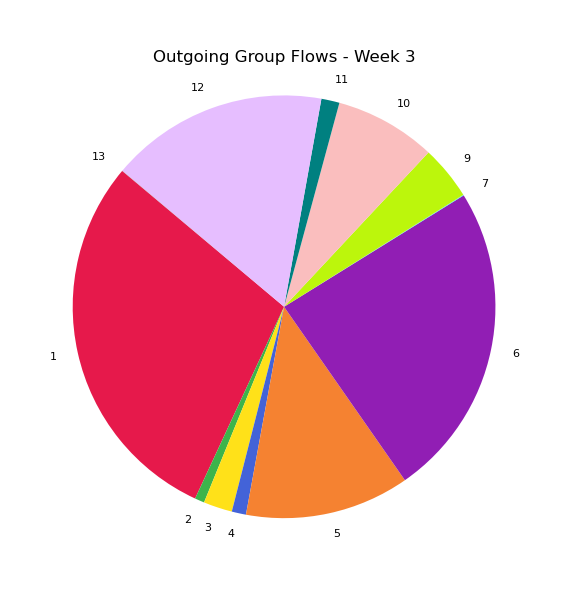

--- Group Flow Counts for Week 4 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week4_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week4_incoming_grouped.png


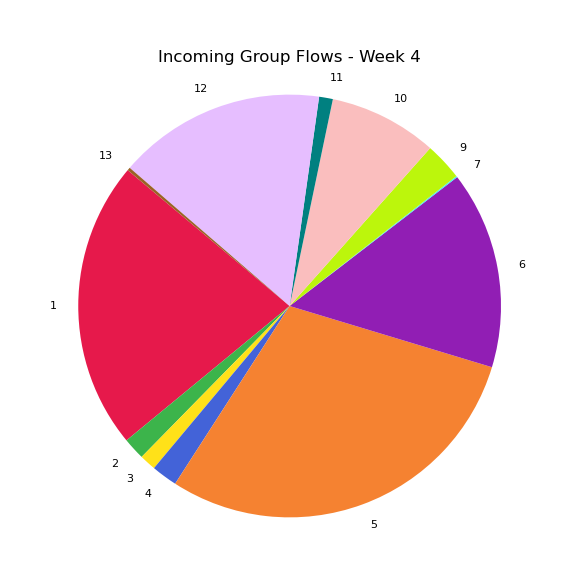

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week4_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week4_outgoing_grouped.png


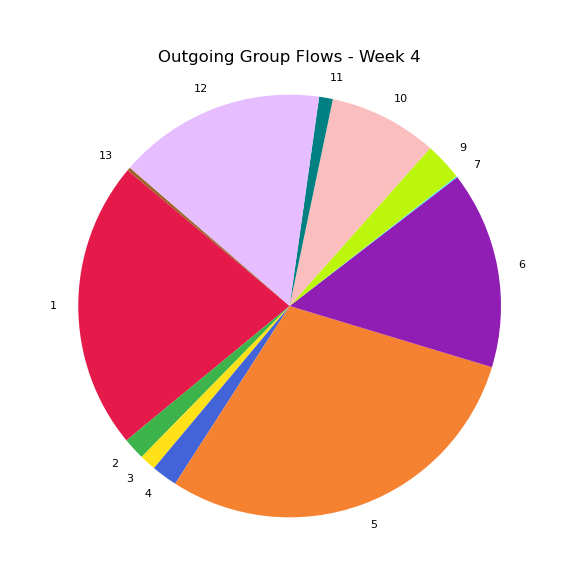

--- Group Flow Counts for Week 5 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week5_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week5_incoming_grouped.png


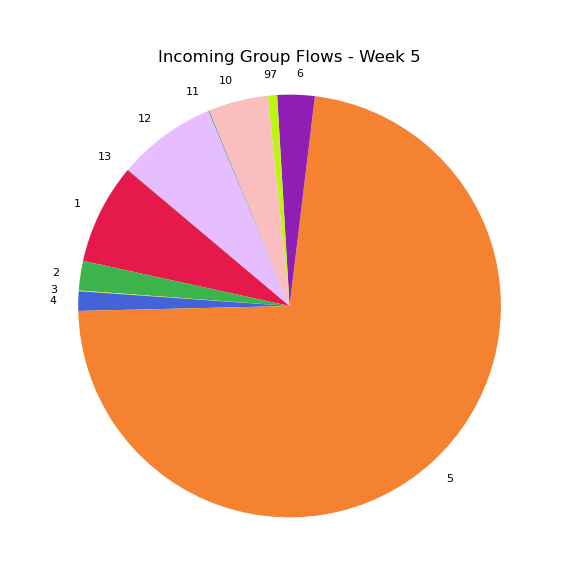

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_week5_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_week5_outgoing_grouped.png


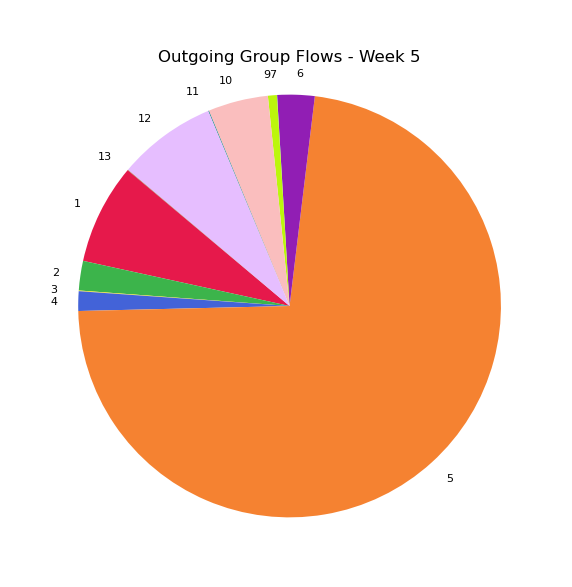

--- Group Flow Counts for Week All ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_weekAll_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_weekAll_incoming_grouped.png


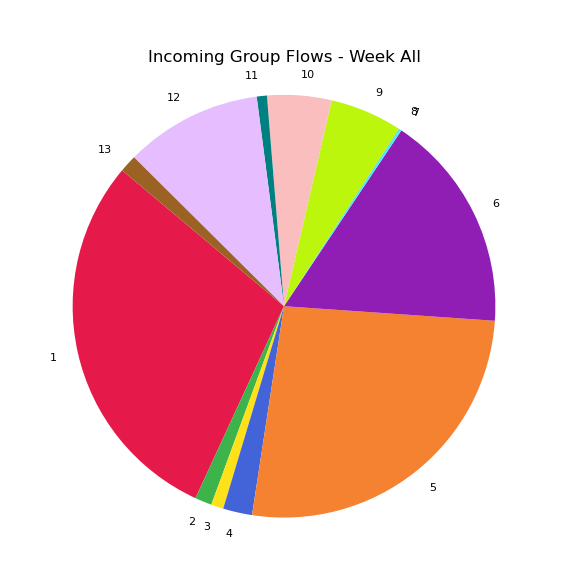

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\eps\2mp_weekAll_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\graphs\sankey_with_pie_plots\png\2mp_weekAll_outgoing_grouped.png


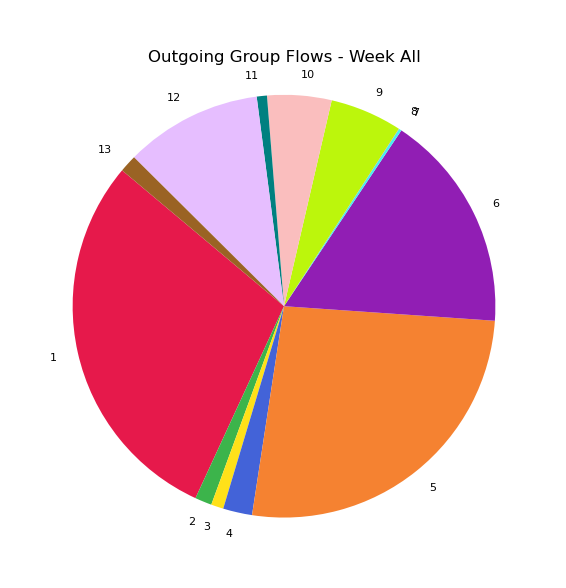

In [147]:
# Pie Flow Chart Grouped 
for week_number in week_numbers:
    arena_data = all_data[all_data['Week_Number'] == week_number]
    create_group_pie_flows(
        arena_data,
        week_number,
        mouse_name=mouse_name
    )

create_group_pie_flows(all_data, "All", mouse_name)